In [1]:
input_data_path = "/content/processed_Ecuador_part_all.gzip.parquet"


#Read data

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
input_data_path = "/content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador"

In [11]:
from pathlib import Path
import pandas as pd

input_data_path = Path(input_data_path)

parquet_files = sorted(input_data_path.glob("*.parquet"))

df = pd.concat(
    [pd.read_parquet(f) for f in parquet_files],
    ignore_index=True,
)

print(df.shape)

(1470529, 19)


In [24]:
from datetime import datetime
from pathlib import Path

# input_data_path is already defined as a Path object in DtuqWVxaPBgu.
# We will derive the output path based on the *name* of the input_data_path directory.

def strip_data_suffix(path: str | Path) -> str:
    """Return a data filename without its parquet compression suffix.

    Args:
        path: Data file path.

    Returns:
        Filename without a recognized data suffix.
    """
    name = Path(path).name
    for suffix in (".gzip.parquet", ".snappy.parquet", ".parquet", ".gzip", ".gz", ".csv"):
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return Path(name).stem # For directory names, .stem is usually the name itself

# Extract the base name of the input directory
dataset_part = strip_data_suffix(input_data_path.name)
# Construct the output path under '../results' using the extracted dataset part as a directory name
dataset_part_path = Path("../results") / dataset_part
output_path = dataset_part_path / "step_Boost"
output_path.mkdir(parents=True, exist_ok=True)
REPORT_PATH = output_path / "progress_report.txt"

def write_report(message: str) -> None:
    """Write a timestamped message to the progress report.

    Args:
        message: Message to write.
    """
    line = f"{datetime.now():%Y-%m-%d %H:%M:%S} | {message}"
    print(line)
    with open(REPORT_PATH, "a", encoding="utf-8") as report_file:
        report_file.write(line + "\n")

write_report(f"Input data path: {input_data_path}")
write_report(f"Output path: {output_path}")

2026-07-27 06:33:12 | Input data path: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador
2026-07-27 06:33:12 | Output path: ../results/Ecuador/step_Boost


In [25]:
unique_control_users = df.loc[df["is_control"] == True, "accountid"].nunique()
print("is_control:TRUE",unique_control_users)
unique_control_users = df.loc[df["is_control"] == False, "accountid"].nunique()
print("is_control:False",unique_control_users)

is_control:TRUE 21138
is_control:False 787


In [26]:
df["is_control"].value_counts()


,count
is_control,
True,770289
False,700240


#EDA

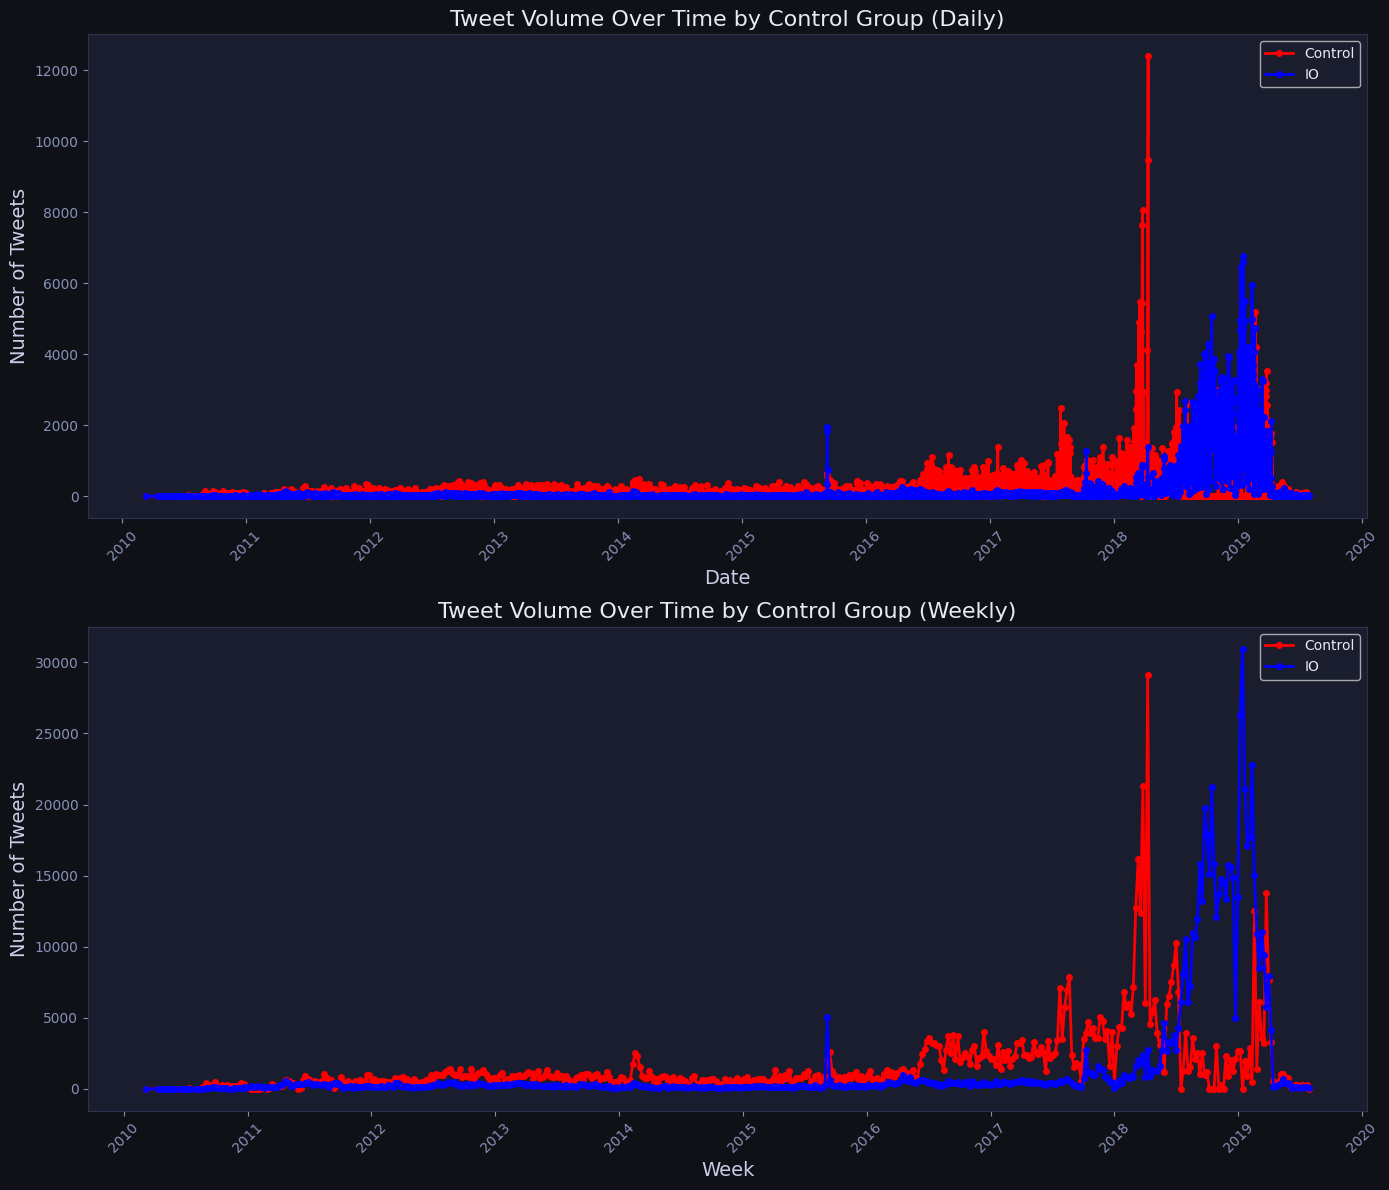

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure post_time is datetime and drop NaNs
df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])

# --- Daily ---
tweets_per_day_control = df.groupby([df["post_time"].dt.date, "is_control"]).size().unstack(fill_value=0)

# --- Weekly ---
df['week'] = df['post_time'].dt.to_period('W')
tweets_per_week_control = df.groupby(['week', 'is_control']).size().unstack(fill_value=0)
weeks_as_dates = tweets_per_week_control.index.to_timestamp()

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for ax, x, data, title, xlabel in [
    (axes[0], tweets_per_day_control.index, tweets_per_day_control, "Tweet Volume Over Time by Control Group (Daily)", "Date"),
    (axes[1], weeks_as_dates, tweets_per_week_control, "Tweet Volume Over Time by Control Group (Weekly)", "Week"),
]:
    ax.plot(x, data[True], label='Control', color='red', marker='o', markersize=4, linewidth=2)
    ax.plot(x, data[False], label='IO', color='blue', marker='o', markersize=4, linewidth=2)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel("Number of Tweets", fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

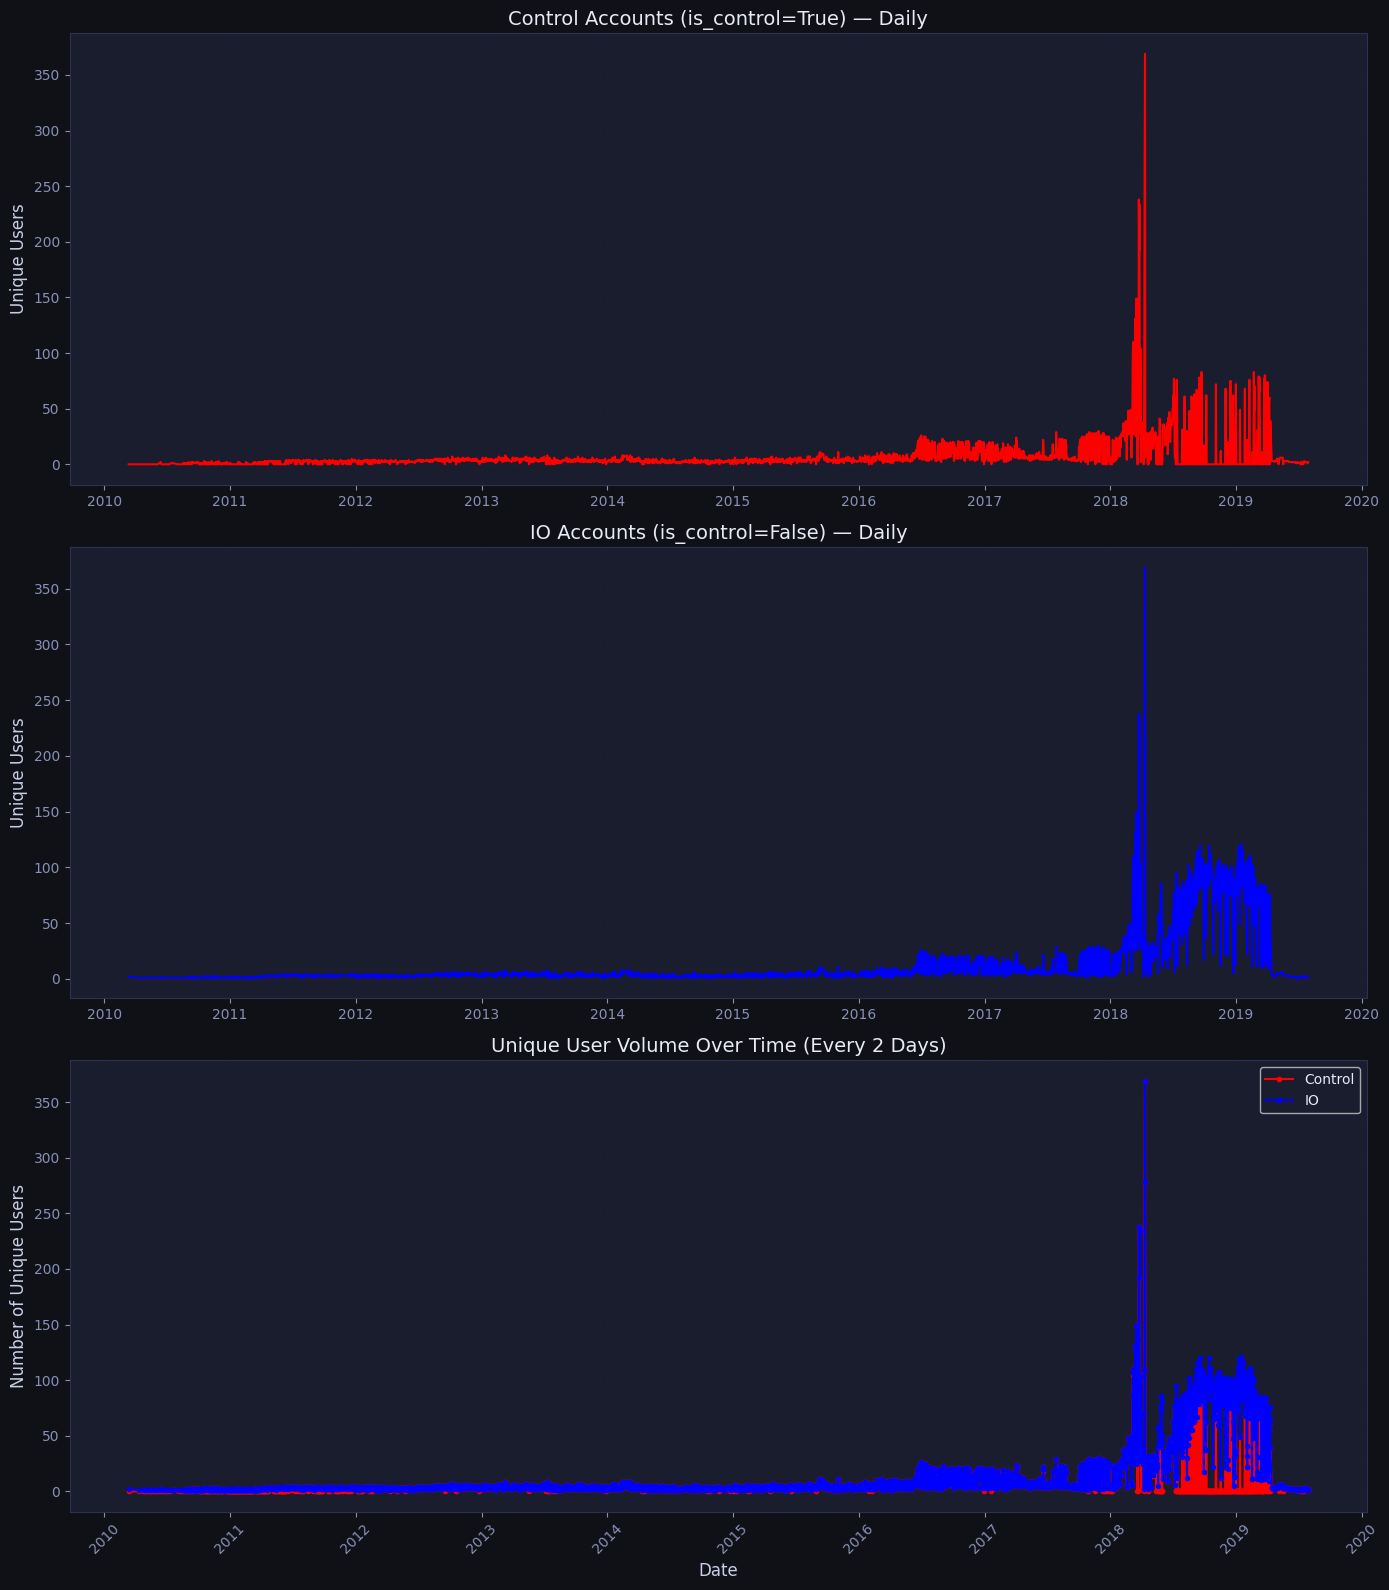

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure post_time is datetime and drop NaNs
df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])

# --- Daily ---
unique_users_per_day = (
    df.groupby([df["post_time"].dt.date, "is_control"])["accountid"]
      .nunique()
      .unstack(fill_value=0)
)

# --- Every 2 Days ---
df['period'] = df['post_time'].dt.to_period('2D')
unique_users_per_period = (
    df.groupby(['period', 'is_control'])['accountid']
      .nunique()
      .unstack(fill_value=0)
)

# --- Plot: 3 subplots ---
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Daily - Control
axes[0].plot(unique_users_per_day.index, unique_users_per_day[True], color='red')
axes[0].set_title("Control Accounts (is_control=True) — Daily", fontsize=14)
axes[0].set_ylabel("Unique Users", fontsize=12)
axes[0].grid(alpha=0.3)

# Daily - IO
axes[1].plot(unique_users_per_day.index, unique_users_per_day[False], color='blue')
axes[1].set_title("IO Accounts (is_control=False) — Daily", fontsize=14)
axes[1].set_ylabel("Unique Users", fontsize=12)
axes[1].grid(alpha=0.3)

# Every 2 Days - Both
axes[2].plot(unique_users_per_period.index.to_timestamp(), unique_users_per_period[True],
             label='Control', color='red', marker='o', markersize=3)
axes[2].plot(unique_users_per_period.index.to_timestamp(), unique_users_per_period[False],
             label='IO', color='blue', marker='o', markersize=3)
axes[2].set_title("Unique User Volume Over Time (Every 2 Days)", fontsize=14)
axes[2].set_xlabel("Date", fontsize=12)
axes[2].set_ylabel("Number of Unique Users", fontsize=12)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#create pipeline Initial boost

In [29]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# ===============================
# PARAMETERS
# ===============================

FREQ        = "5min"
Z_THRESHOLD = 3
WINDOW      = pd.Timedelta(minutes=5)

# ===============================
# 1. PREPARE DATA
# ===============================

df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])

# ===============================
# 2. BUILD TIME SERIES
# ===============================

volume_g = (
    df.groupby(pd.Grouper(key="post_time", freq=FREQ))
      .size()
      .to_frame(name="volume")
)

# ===============================
# 3. COMPUTE DELTA & Z-SCORE
# ===============================

volume_g["delta"] = volume_g["volume"].diff()

volume_g["z_score"] = (
    (volume_g["delta"] - volume_g["delta"].mean())
    / volume_g["delta"].std()
)

volume_g = volume_g.dropna()

# ===============================
# 4. IDENTIFY BURSTS
# ===============================

bursts_g = volume_g[volume_g["z_score"] > Z_THRESHOLD]

print(f"Detected {len(bursts_g)} burst windows")

# ===============================
# 5. COMPUTE BOOST AUTHORS
# ===============================

boost_records_g = []

for burst_time, row in tqdm(
    bursts_g.iterrows(),
    total=len(bursts_g),
    desc="Processing bursts"
):

    prior_posts = df[
        (df["post_time"] >= burst_time - WINDOW) &
        (df["post_time"] <  burst_time)
    ]

    unique_users = prior_posts["accountid"].unique()

    if len(unique_users) == 0:
        continue

    burst_weight = row["delta"] / len(unique_users)

    for user in unique_users:
        boost_records_g.append(
            (user, burst_weight, burst_time)
        )

# ===============================
# 6. FINAL BOOST SCORE
# ===============================

boost_df_g = pd.DataFrame(
    boost_records_g,
    columns=["accountid", "burst_weight", "burst_time"]
)

boost_df_g["burst_time"] = pd.to_datetime(boost_df_g["burst_time"])

boost_scores_g = (
    boost_df_g
    .groupby("accountid")["burst_weight"]
    .sum()
    .sort_values(ascending=False)
)

boost_df_final_g = boost_scores_g.reset_index()
boost_df_final_g.columns = ["accountid", "boost_score"]

boost_merged_g = boost_df_final_g.merge(
    df[["accountid", "is_control"]].drop_duplicates(),
    on="accountid",
    how="left"
)

print("\nTop Boost Authors:")
print(boost_merged_g.head(20))




Detected 5940 burst windows


Processing bursts: 100%|██████████| 5940/5940 [00:51<00:00, 115.41it/s]



Top Boost Authors:
                                     accountid   boost_score  is_control
0   9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115  10325.216940       False
1   70977662b5d96b2cf7604f9de940a581576abcd991   4050.939597       False
2   71b45b9cfbe033acf94c15763207cc9f35746ad22a   3853.124571       False
3   cea0b6abc111f3ee47a98af23b1a594373469df377   2659.149089       False
4   142f97ce405a79eb952d0f2104b784a0488fc08e2a   2514.453525       False
5   0d3b88567bf65211bb328ab87185c347edd4f29f9a   2073.440275       False
6   cd0b8e047f5b20eed79cf903fd915afdf4458bc3b4   2069.751054       False
7   4356e554e26d3b89f45ecfdee41cc2bd57a86bf2bb   1967.342615       False
8   fa300e59c6f5cb1d7893b6a96cf9770fc8ea185342   1953.313342       False
9   6d5c983bd23cf9fcc259f8da6e7500ad270f06e0ca   1860.241637       False
10  b2ee4f11ad64bd65b56ef6ea0a24e929c57ed51ef1   1740.010329       False
11  ab27c1a26d0d24fdea455ac9d7272fb92cccc1c46f   1688.386192       False
12  096ca573d172abad763b2a566e6

In [30]:
# ===============================
# 7. SAVE
# ===============================

boost_df_g.to_csv(output_path / "boost_df_raw_global.csv", index=False)
boost_merged_g.to_csv(output_path / "boost_merged_global.csv", index=False)

print("\nSaved:")
print(f"  boost_df_raw_global.csv  — {len(boost_df_g):,} rows")
print(f"  boost_merged_global.csv  — {len(boost_merged_g):,} rows")


Saved:
  boost_df_raw_global.csv  — 34,015 rows
  boost_merged_global.csv  — 6,369 rows


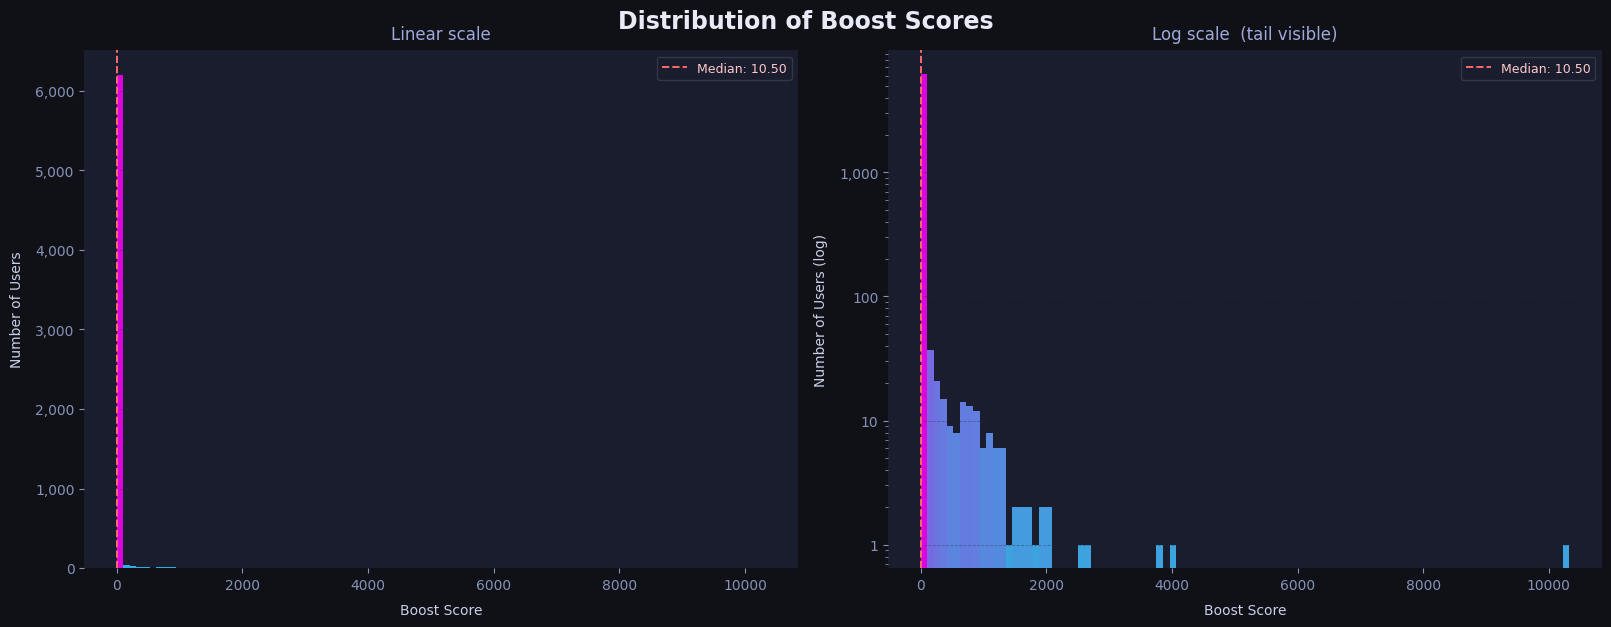

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ----------------------------------------------------- #
# Style setup
# ----------------------------------------------------- #

def plot_boost_distribution(data, title="Distribution of Boost Scores",
                             bins=100, save_path="boost_score_distribution.png"):

    plt.rcParams.update({
        "figure.facecolor": "#0f1117",
        "axes.facecolor":   "#1a1d2e",
        "axes.edgecolor":   "#2e3250",
        "axes.labelcolor":  "#c9cfe8",
        "xtick.color":      "#8891b8",
        "ytick.color":      "#8891b8",
        "text.color":       "#e8eaf6",
        "grid.color":       "#252840",
        "grid.linestyle":   "--",
        "grid.linewidth":   0.6,
        "font.family":      "DejaVu Sans",
    })

    data   = data.dropna()
    bins   = np.linspace(data.min(), data.max(), bins)
    cmap   = plt.cm.cool
    ACCENT = "#5c7cfa"

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
    fig.suptitle(title, fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)

    # ── Panel 1 : Linear ─────────────────────────────────────────────────────────
    ax1 = axes[0]
    n, _, patches = ax1.hist(data, bins=bins, color=ACCENT, edgecolor="none", alpha=0.85)
    for count, patch in zip(n, patches):
        patch.set_facecolor(cmap(count / n.max() * 0.8 + 0.2))

    ax1.set_title("Linear scale", fontsize=12, color="#9fa8da", pad=8)
    ax1.set_xlabel("Boost Score", labelpad=8)
    ax1.set_ylabel("Number of Users", labelpad=8)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax1.grid(axis="y", alpha=0.4)
    ax1.spines[:].set_visible(False)

    # ── Panel 2 : Log Y ───────────────────────────────────────────────────────
    ax2 = axes[1]
    n2, _, patches2 = ax2.hist(data, bins=bins, color=ACCENT, edgecolor="none", alpha=0.85, log=True)
    max_n2 = n2[n2 > 0].max()
    for count, patch in zip(n2, patches2):
        if count > 0:
            patch.set_facecolor(cmap(np.log1p(count) / np.log1p(max_n2) * 0.8 + 0.2))

    ax2.set_title("Log scale  (tail visible)", fontsize=12, color="#9fa8da", pad=8)
    ax2.set_xlabel("Boost Score", labelpad=8)
    ax2.set_ylabel("Number of Users (log)", labelpad=8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax2.grid(axis="y", alpha=0.4)
    ax2.spines[:].set_visible(False)

    # ── Median line ───────────────────────────────────────────────────────────
    median_val = data.median()
    for ax in axes:
        ax.axvline(median_val, color="#ff6b6b", linewidth=1.4,
                   linestyle="--", label=f"Median: {median_val:.2f}")
        ax.legend(framealpha=0.15, labelcolor="#ffc9c9", fontsize=9)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


# Usage:
plot_boost_distribution(boost_merged_g["boost_score"])

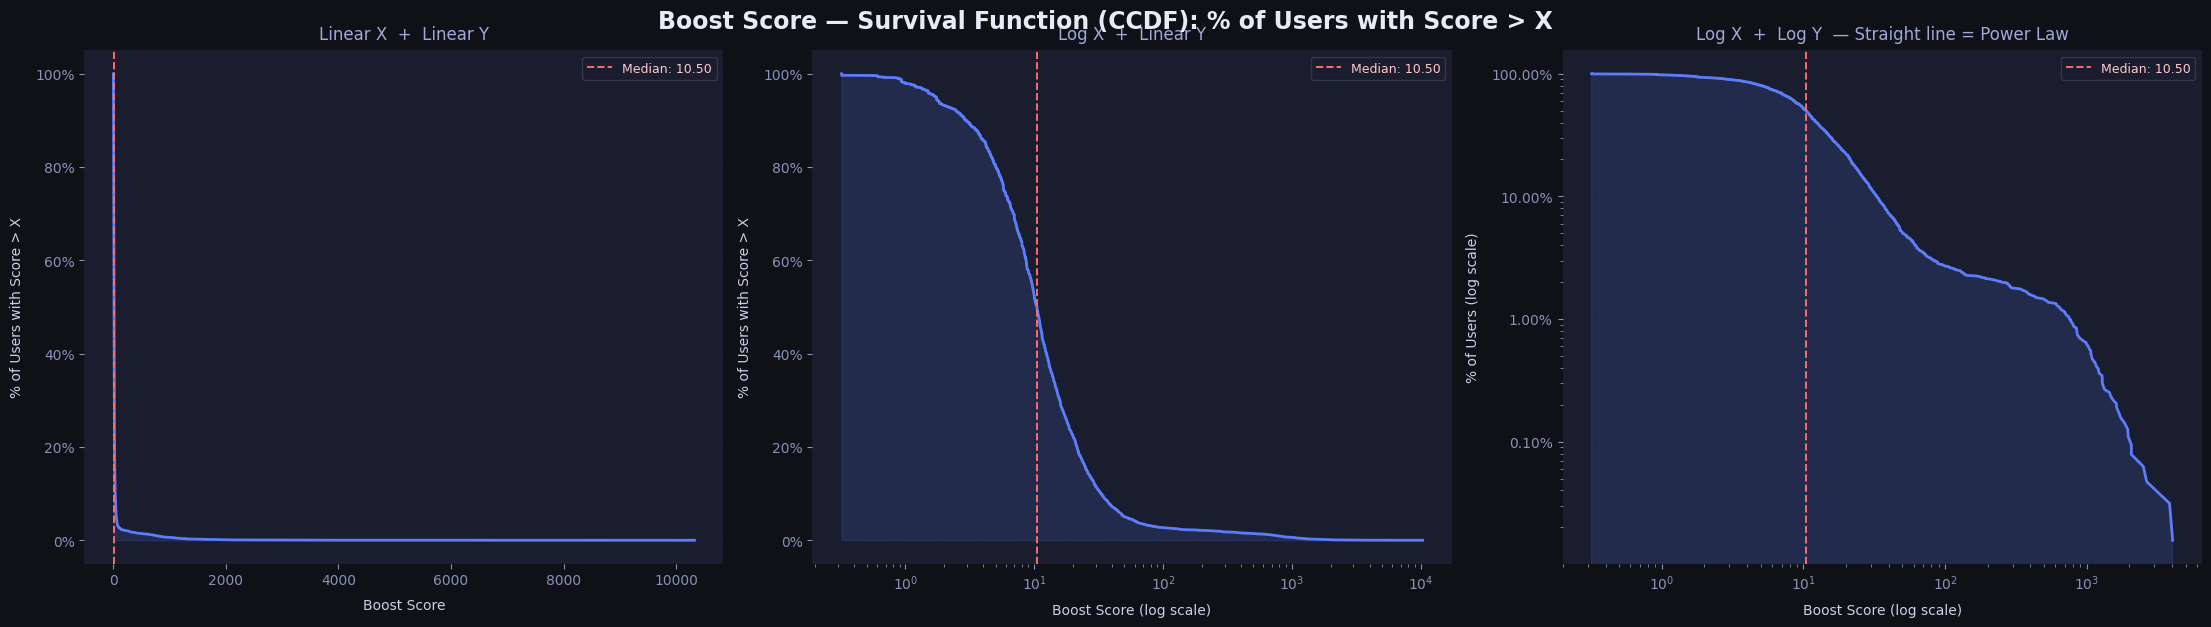

In [32]:
def plot_boost_ccdf(data, title="Boost Score — Survival Function (CCDF): % of Users with Score > X",
                    save_path="boost_score_ccdf.png"):

    plt.rcParams.update({
        "figure.facecolor": "#0f1117",
        "axes.facecolor":   "#1a1d2e",
        "axes.edgecolor":   "#2e3250",
        "axes.labelcolor":  "#c9cfe8",
        "xtick.color":      "#8891b8",
        "ytick.color":      "#8891b8",
        "text.color":       "#e8eaf6",
        "grid.color":       "#252840",
        "grid.linestyle":   "--",
        "grid.linewidth":   0.6,
        "font.family":      "DejaVu Sans",
    })

    # ── Data preparation ──────────────────────────────────────────────────────
    data       = data.dropna()
    data_pos   = np.sort(data[data > 0])
    ccdf       = 1 - np.arange(1, len(data_pos) + 1) / len(data_pos)
    median_val = data.median()
    ACCENT     = "#5c7cfa"

    fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
    fig.suptitle(title, fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)

    # ── Panel configs ─────────────────────────────────────────────────────────
    panels = [
        dict(ax=axes[0], xscale="linear", yscale="linear",
             title="Linear X  +  Linear Y",     xlabel="Boost Score"),
        dict(ax=axes[1], xscale="log",    yscale="linear",
             title="Log X  +  Linear Y",         xlabel="Boost Score (log scale)"),
        dict(ax=axes[2], xscale="log",    yscale="log",
             title="Log X  +  Log Y  — Straight line = Power Law",
             xlabel="Boost Score (log scale)"),
    ]

    for p in panels:
        ax   = p["ax"]
        mask = ccdf > 0 if p["yscale"] == "log" else slice(None)
        x, y = data_pos[mask], ccdf[mask]

        ax.plot(x, y, color=ACCENT, linewidth=2)
        ax.fill_between(x, y, alpha=0.15, color=ACCENT)
        ax.set_xscale(p["xscale"])
        ax.set_yscale(p["yscale"])
        ax.set_title(p["title"], fontsize=12, color="#9fa8da", pad=8)
        ax.set_xlabel(p["xlabel"], labelpad=8)
        ax.set_ylabel("% of Users with Score > X" if p["yscale"] == "linear"
                      else "% of Users (log scale)", labelpad=8)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(
            xmax=1, decimals=0 if p["yscale"] == "linear" else 2))
        if p["xscale"] == "log":
            ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation())
        ax.grid(alpha=0.4)
        ax.spines[:].set_visible(False)

    # ── Median line ───────────────────────────────────────────────────────────
    for ax in axes:
        ax.axvline(median_val, color="#ff6b6b", linewidth=1.4,
                   linestyle="--", label=f"Median: {median_val:.2f}")
        ax.legend(framealpha=0.15, labelcolor="#ffc9c9", fontsize=9)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


# Usage:
plot_boost_ccdf(boost_merged_g["boost_score"])

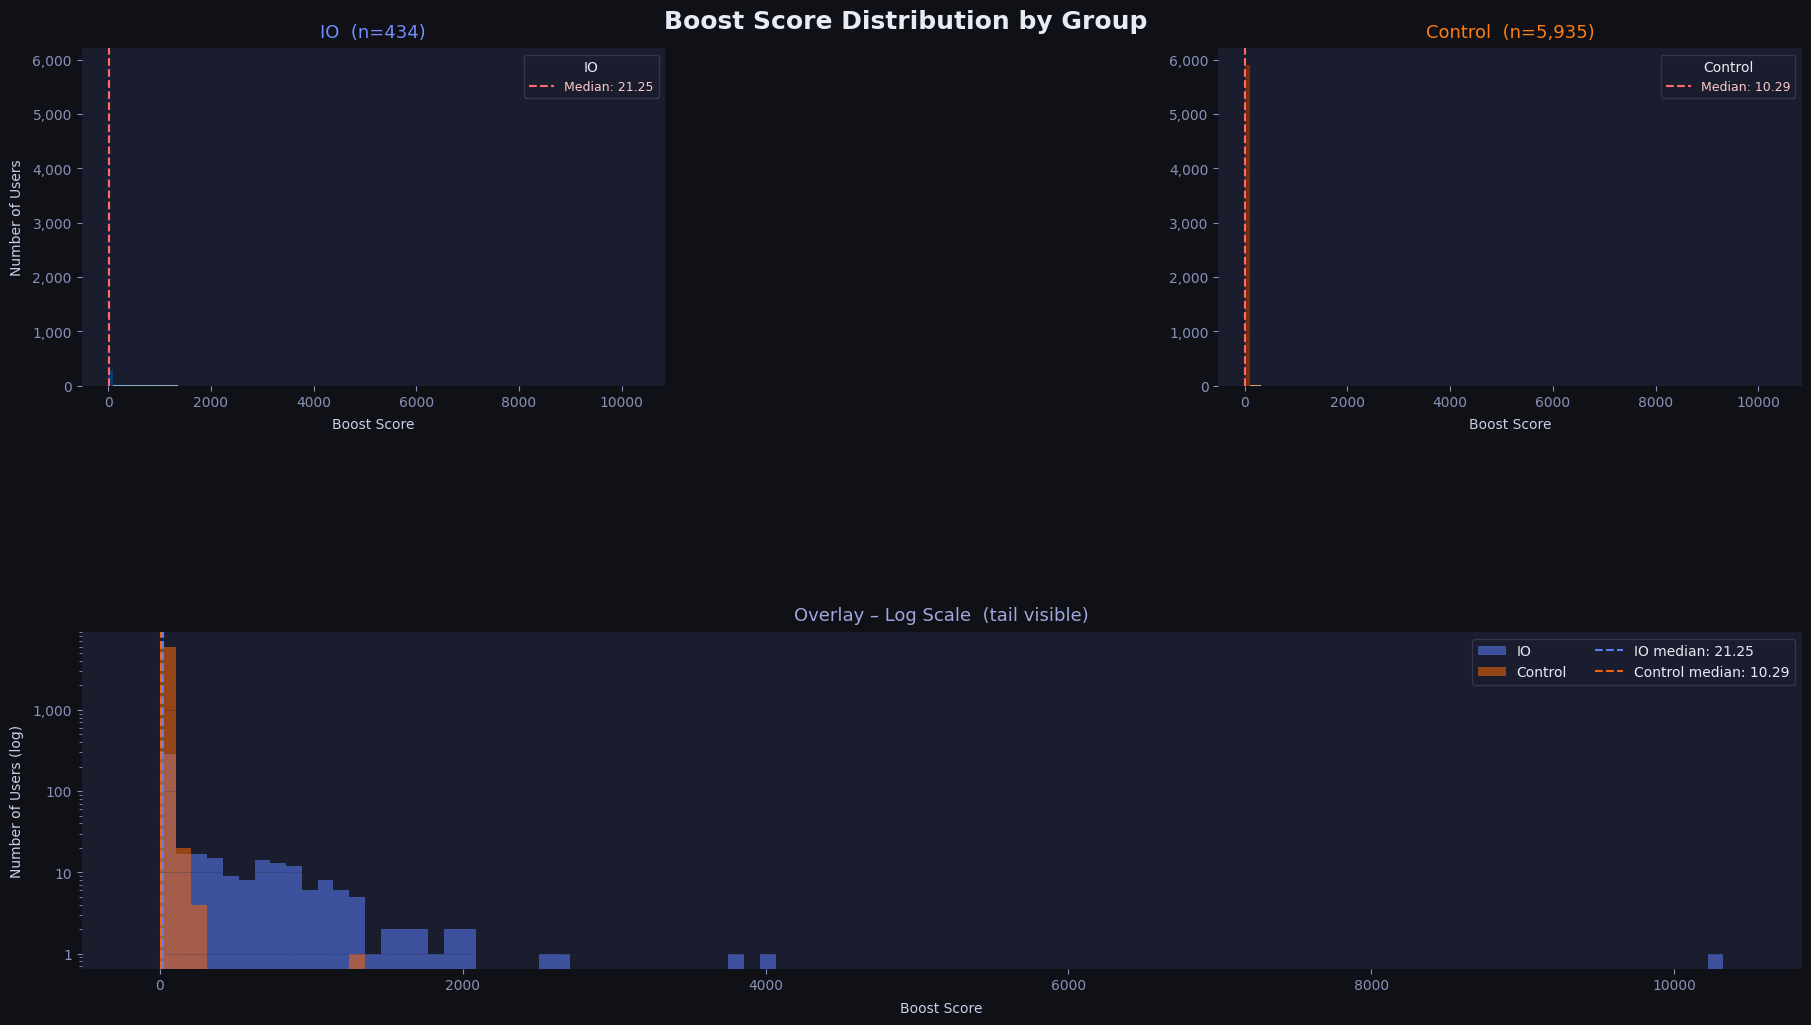

In [33]:
def plot_boost_by_group(df, score_col="boost_score", group_col="is_control",
                        title="Boost Score Distribution by Group",
                        save_path="boost_score_by_group.png"):

    plt.rcParams.update({
        "figure.facecolor": "#0f1117",
        "axes.facecolor":   "#1a1d2e",
        "axes.edgecolor":   "#2e3250",
        "axes.labelcolor":  "#c9cfe8",
        "xtick.color":      "#8891b8",
        "ytick.color":      "#8891b8",
        "text.color":       "#e8eaf6",
        "grid.color":       "#252840",
        "grid.linestyle":   "--",
        "grid.linewidth":   0.6,
        "font.family":      "DejaVu Sans",
    })

    COLOR_IO      = "#5c7cfa"
    COLOR_CONTROL = "#f76707"

    io_data      = df[df[group_col] == False][score_col].dropna()
    control_data = df[df[group_col] == True][score_col].dropna()

    all_data = np.concatenate([io_data, control_data])
    bins     = np.linspace(all_data.min(), all_data.max(), 100)

    def styled_hist(ax, data, color, label, log=False):
        n, _, patches = ax.hist(data, bins=bins, color=color,
                                edgecolor="none", alpha=0.85, log=log)
        cmap  = plt.cm.Blues if color == COLOR_IO else plt.cm.Oranges
        max_n = n[n > 0].max() if log else n.max()
        norm  = np.log1p if log else lambda x: x
        for cnt, patch in zip(n, patches):
            if cnt > 0:
                patch.set_facecolor(cmap(norm(cnt) / norm(max_n) * 0.6 + 0.35))
        med = data.median()
        ax.axvline(med, color="#ff6b6b", linewidth=1.5, linestyle="--",
                   label=f"Median: {med:.2f}")
        ax.legend(framealpha=0.15, labelcolor="#ffc9c9", fontsize=9,
                  title=label, title_fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        ax.grid(axis="y", alpha=0.4)
        ax.spines[:].set_visible(False)

    # ── Layout ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    fig.suptitle(title, fontsize=18, fontweight="bold", color="#e8eaf6", y=1.01)

    gs     = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.28)
    ax_io  = fig.add_subplot(gs[0, 0])
    ax_ctl = fig.add_subplot(gs[0, 1], sharey=ax_io, sharex=ax_io)
    ax_ovr = fig.add_subplot(gs[1, :], sharex=ax_io)

    # ── Top-left: IO ──────────────────────────────────────────────────────────
    styled_hist(ax_io, io_data, COLOR_IO, "IO")
    ax_io.set_title(f"IO  (n={len(io_data):,})", fontsize=13, color="#748ffc", pad=8)
    ax_io.set_xlabel("Boost Score", labelpad=6)
    ax_io.set_ylabel("Number of Users", labelpad=6)

    # ── Top-right: Control ────────────────────────────────────────────────────
    styled_hist(ax_ctl, control_data, COLOR_CONTROL, "Control")
    ax_ctl.set_title(f"Control  (n={len(control_data):,})", fontsize=13,
                     color="#fd7e14", pad=8)
    ax_ctl.set_xlabel("Boost Score", labelpad=6)
    ax_ctl.tick_params(labelleft=True)

    # ── Bottom: Overlay ───────────────────────────────────────────────────────
    ax_ovr.hist(io_data,      bins=bins, alpha=0.55, color=COLOR_IO,
                edgecolor="none", log=True, label="IO")
    ax_ovr.hist(control_data, bins=bins, alpha=0.55, color=COLOR_CONTROL,
                edgecolor="none", log=True, label="Control")

    for val, col, lbl in [
        (io_data.median(),      COLOR_IO,      f"IO median: {io_data.median():.2f}"),
        (control_data.median(), COLOR_CONTROL, f"Control median: {control_data.median():.2f}"),
    ]:
        ax_ovr.axvline(val, color=col, linewidth=1.5, linestyle="--", label=lbl)

    ax_ovr.set_title("Overlay – Log Scale  (tail visible)", fontsize=13,
                     color="#9fa8da", pad=8)
    ax_ovr.set_xlabel("Boost Score", labelpad=6)
    ax_ovr.set_ylabel("Number of Users (log)", labelpad=6)
    ax_ovr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax_ovr.legend(framealpha=0.15, fontsize=10, ncol=2)
    ax_ovr.grid(axis="y", alpha=0.4)
    ax_ovr.spines[:].set_visible(False)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


# Usage:
plot_boost_by_group(boost_merged_g)

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_boost_boxplot(df, score_col="boost_score", group_col="is_control",
                       title="Boost Score Distribution by Group",
                       save_path="boost_boxplot.png"):

    plt.rcParams.update({
        "figure.facecolor": "#0f1117",
        "axes.facecolor":   "#1a1d2e",
        "axes.edgecolor":   "#2e3250",
        "axes.labelcolor":  "#c9cfe8",
        "xtick.color":      "#8891b8",
        "ytick.color":      "#8891b8",
        "text.color":       "#e8eaf6",
        "grid.color":       "#252840",
        "grid.linestyle":   "--",
        "grid.linewidth":   0.6,
        "font.family":      "DejaVu Sans",
    })

    COLOR_IO      = "#5c7cfa"
    COLOR_CONTROL = "#f76707"

    io_data      = df[df[group_col] == False][score_col].dropna()
    control_data = df[df[group_col] == True ][score_col].dropna()

    fig, ax = plt.subplots(figsize=(10, 7))

    for data, pos, color, label in zip(
        [io_data,  control_data],
        [1,        2],
        [COLOR_IO, COLOR_CONTROL],
        ["IO",     "Control"],
    ):
        ax.boxplot(
            data, positions=[pos], widths=0.45,
            patch_artist=True, notch=True, showfliers=False,
            medianprops=dict(color="#ffffff", linewidth=2.5),
            boxprops=dict(facecolor=color, alpha=0.35, linewidth=0),
            whiskerprops=dict(color=color, linewidth=1.4, linestyle="--"),
            capprops=dict(color=color, linewidth=2),
        )

        # ── jittered outliers (above 95th pct) ───────────────────────────
        outliers = data[data > np.percentile(data, 95)]
        jitter   = np.random.uniform(-0.12, 0.12, size=len(outliers))
        ax.scatter(pos + jitter, outliers, color=color, alpha=0.25,
                   s=12, linewidths=0, zorder=3)

        # ── annotate median & IQR ─────────────────────────────────────────
        med, q1, q3 = data.median(), data.quantile(0.25), data.quantile(0.75)
        y0 = ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1
        ax.text(pos, y0,
                f"Median: {med:,.1f}\nIQR: {q1:,.0f}–{q3:,.0f}",
                ha="center", va="bottom", fontsize=8.5, color=color,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#1a1d2e",
                          edgecolor=color, alpha=0.7))

    # ── axes ──────────────────────────────────────────────────────────────────
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", alpha=0.4)
    ax.grid(axis="x", visible=False)
    ax.spines[:].set_visible(False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["IO", "Control"], fontsize=13)
    ax.set_xlabel("Group", labelpad=10, fontsize=12)
    ax.set_ylabel("Boost Score  (log scale)", labelpad=10, fontsize=12)
    ax.set_title(title, fontsize=16, fontweight="bold", color="#e8eaf6", pad=16)

    ax.legend(handles=[
        mpatches.Patch(facecolor=COLOR_IO,      alpha=0.7, label=f"IO  (n={len(io_data):,})"),
        mpatches.Patch(facecolor=COLOR_CONTROL, alpha=0.7, label=f"Control  (n={len(control_data):,})"),
    ], framealpha=0.15, fontsize=10, loc="upper right")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()





In [35]:
import pandas as pd

boost_merged_g = pd.read_csv(output_path / "boost_merged_global.csv")
boost_df_g = pd.read_csv(output_path / "boost_df_raw_global.csv")

# Convert 'burst_time' to datetime after loading from CSV
boost_df_g['burst_time'] = pd.to_datetime(boost_df_g['burst_time'])


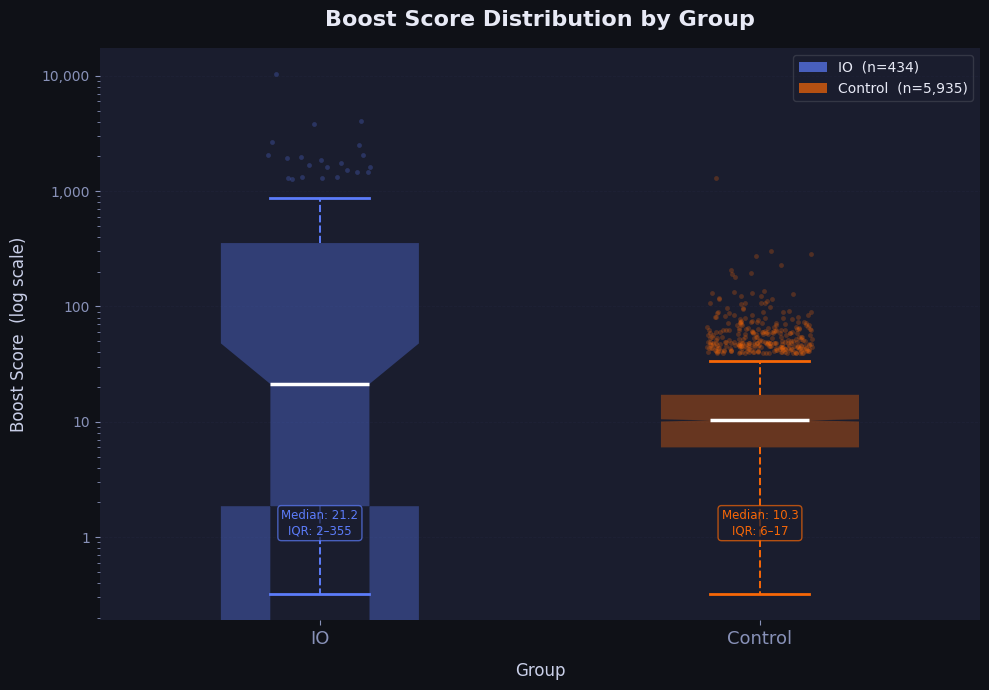

In [21]:
plot_boost_boxplot(boost_merged_g)

consistency_global.csv — 6,369 rows


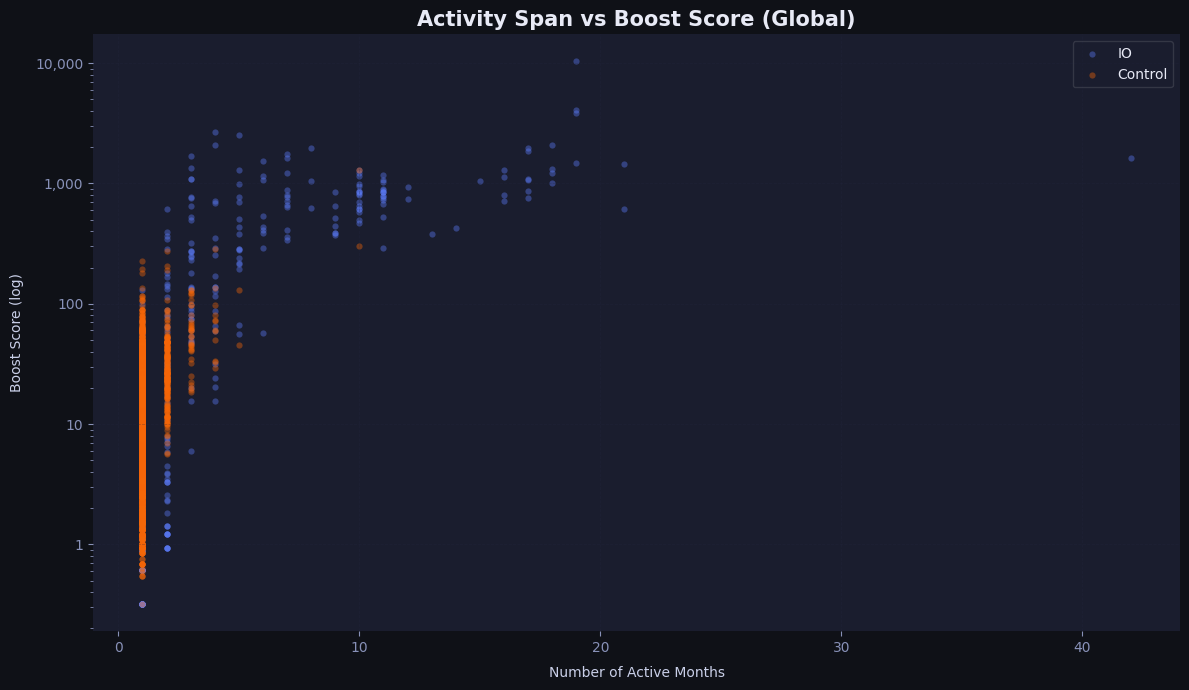

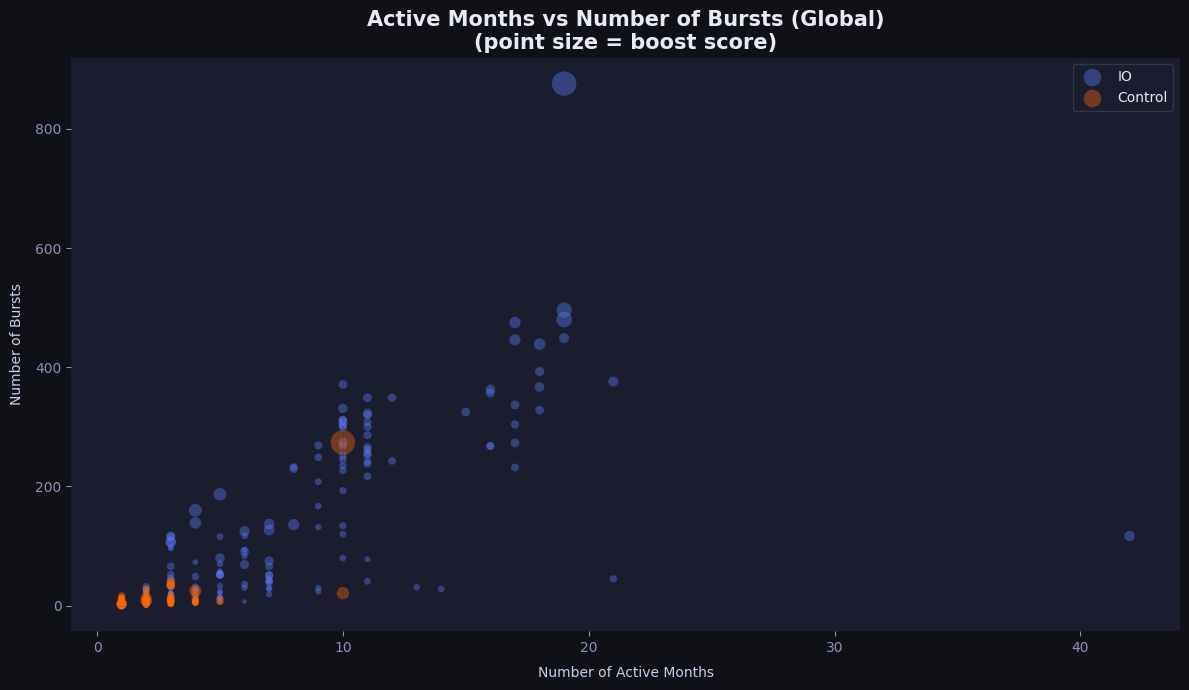

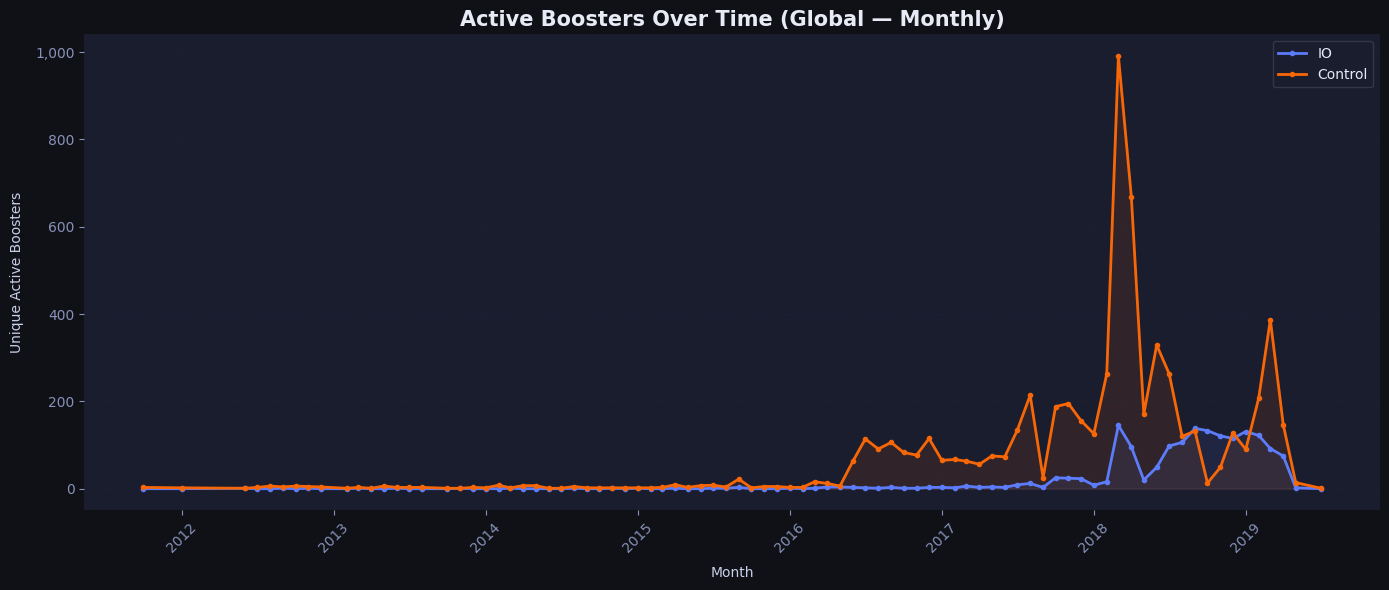

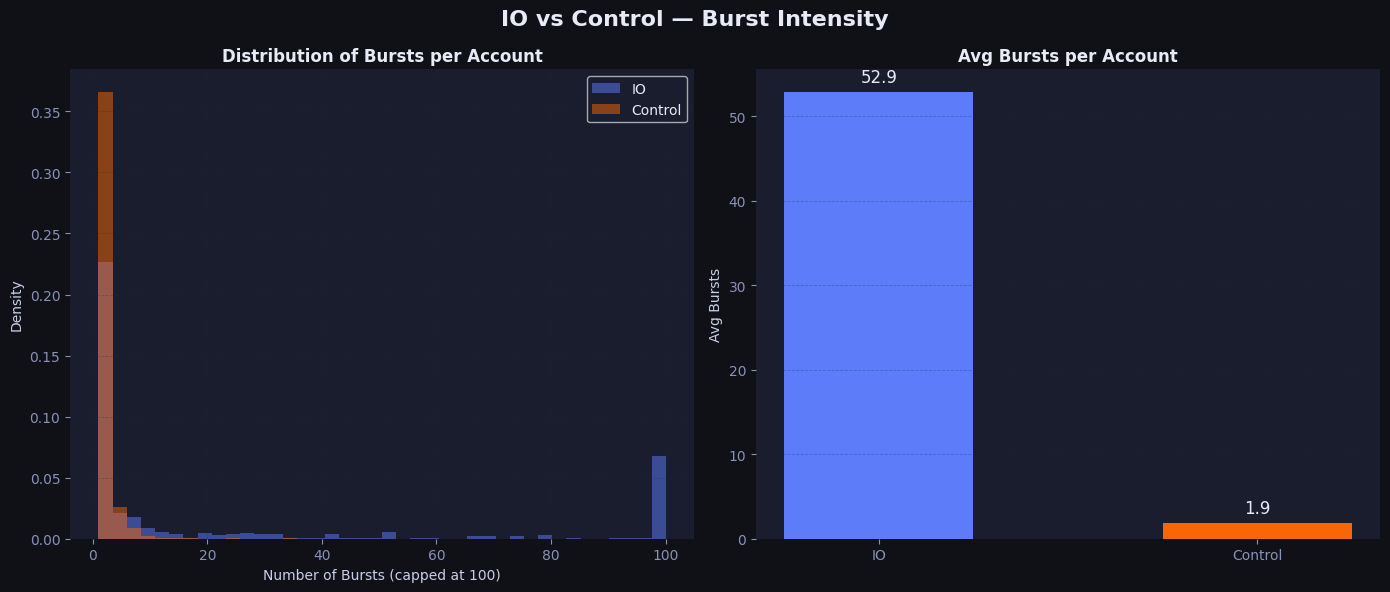

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d2e",
    "axes.edgecolor":   "#2e3250",
    "axes.labelcolor":  "#c9cfe8",
    "xtick.color":      "#8891b8",
    "ytick.color":      "#8891b8",
    "text.color":       "#e8eaf6",
    "grid.color":       "#252840",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
})

COLOR_IO      = "#5c7cfa"
COLOR_CONTROL = "#f76707"



consistency_g = (
    boost_df_g.groupby("accountid")
    .agg(
        total_score = ("burst_weight", "sum"),
        n_bursts    = ("burst_time",   "count"),
        n_months    = ("burst_time",   lambda x: x.dt.to_period("M").nunique()),
        first_burst = ("burst_time",   "min"),
        last_burst  = ("burst_time",   "max"),
    )
    .reset_index()
)

consistency_g["active_months_span"] = (
    (consistency_g["last_burst"] - consistency_g["first_burst"])
    / pd.Timedelta(days=30)
).round(1)

consistency_g = consistency_g.merge(
    df[["accountid", "is_control"]].drop_duplicates(),
    on="accountid", how="left"
)

consistency_g.to_csv("consistency_global.csv", index=False)
print(f"consistency_global.csv — {len(consistency_g):,} rows")

# =====================================================
# PLOTS
# =====================================================

io_g  = consistency_g[consistency_g["is_control"] == False]
ctl_g = consistency_g[consistency_g["is_control"] == True]

# ── 1. Scatter: n_months vs boost_score ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7))
for data, color, label in [(io_g, COLOR_IO, "IO"), (ctl_g, COLOR_CONTROL, "Control")]:
    ax.scatter(data["n_months"], data["total_score"],
               color=color, alpha=0.4, s=20, label=label, linewidths=0)

ax.set_yscale("log")
ax.set_title("Activity Span vs Boost Score (Global)", fontsize=15, fontweight="bold", color="#e8eaf6")
ax.set_xlabel("Number of Active Months", labelpad=8)
ax.set_ylabel("Boost Score (log)", labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(framealpha=0.15, fontsize=10)
ax.grid(alpha=0.3)
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig("g_scatter_months_vs_score.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# ── 2. Scatter: n_months vs n_bursts (במקום n_entities שאין בשיטה זו) ────────

fig, ax = plt.subplots(figsize=(12, 7))
for data, color, label in [(io_g, COLOR_IO, "IO"), (ctl_g, COLOR_CONTROL, "Control")]:
    ax.scatter(data["n_months"], data["n_bursts"],
               s=data["total_score"] / data["total_score"].max() * 300 + 10,
               color=color, alpha=0.4, label=label, linewidths=0)

ax.set_title("Active Months vs Number of Bursts (Global)\n(point size = boost score)",
             fontsize=15, fontweight="bold", color="#e8eaf6")
ax.set_xlabel("Number of Active Months", labelpad=8)
ax.set_ylabel("Number of Bursts", labelpad=8)
ax.legend(framealpha=0.15, fontsize=10)
ax.grid(alpha=0.3)
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig("g_scatter_bursts_vs_months.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# ── 3. Timeline: active boosters over time ────────────────────────────────────

boost_df_g["month"] = boost_df_g["burst_time"].dt.to_period("M")

timeline_g = (
    boost_df_g.merge(consistency_g[["accountid", "is_control"]], on="accountid", how="left")
    .groupby(["month", "is_control"])["accountid"]
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
x = timeline_g.index.to_timestamp()

for col, color, label in [(False, COLOR_IO, "IO"), (True, COLOR_CONTROL, "Control")]:
    if col in timeline_g.columns:
        ax.plot(x, timeline_g[col], color=color, linewidth=2, label=label, marker="o", markersize=3)
        ax.fill_between(x, timeline_g[col], alpha=0.1, color=color)

ax.set_title("Active Boosters Over Time (Global — Monthly)", fontsize=15, fontweight="bold", color="#e8eaf6")
ax.set_xlabel("Month", labelpad=8)
ax.set_ylabel("Unique Active Boosters", labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(framealpha=0.15, fontsize=10)
ax.grid(alpha=0.3)
ax.spines[:].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("g_timeline_boosters.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()





fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, color, label in [
    (axes[0], io_g,  COLOR_IO,      "IO"),
    (axes[0], ctl_g, COLOR_CONTROL, "Control")
]:
    ax.hist(data["n_bursts"].clip(upper=100), bins=40,
            color=color, alpha=0.5, label=label, density=True)

axes[0].set_title("Distribution of Bursts per Account", fontweight="bold")
axes[0].set_xlabel("Number of Bursts (capped at 100)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].spines[:].set_visible(False)

ax2 = axes[1]
bars = ax2.bar(["IO", "Control"],
               [io_g["n_bursts"].mean(), ctl_g["n_bursts"].mean()],
               color=[COLOR_IO, COLOR_CONTROL], width=0.5)
ax2.bar_label(bars, fmt="%.1f", padding=4, color="#e8eaf6", fontsize=12)
ax2.set_title("Avg Bursts per Account", fontweight="bold")
ax2.set_ylabel("Avg Bursts")
ax2.grid(alpha=0.3, axis="y")
ax2.spines[:].set_visible(False)

plt.suptitle("IO vs Control — Burst Intensity", fontsize=16, fontweight="bold", color="#e8eaf6")
plt.tight_layout()
plt.savefig("burst_intensity.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## Deliverable 1 — Ranked list of boost authors driving discourse acceleration

Turns the sorted `boost_merged_g` from the pipeline cell above into an explicit
ranking. Adds a `rank` column, each author's share of the total boost score, and
the cumulative share, so the head of the distribution can be quoted directly
("the top N accounts carry 50% of all boost").

Outputs, written to `output_path`:

| file | contents |
|---|---|
| `boost_authors_ranked.csv` | every scored account, ranked |
| `boost_authors_top100.csv` | top `TOP_N_AUTHORS` only |

In [37]:
import pandas as pd

boost_ranked = boost_merged_g.sort_values("boost_score", ascending=False).reset_index(drop=True)
boost_ranked.insert(0, "rank", boost_ranked.index + 1)
boost_ranked["pct_of_total_boost"] = (
    100 * boost_ranked["boost_score"] / boost_ranked["boost_score"].sum()
)
boost_ranked["cum_pct"] = boost_ranked["pct_of_total_boost"].cumsum()

boost_ranked.to_csv(output_path / "boost_authors_ranked.csv", index=False)

TOP_N_AUTHORS = 100
boost_ranked.head(TOP_N_AUTHORS).to_csv(
    output_path / f"boost_authors_top{TOP_N_AUTHORS}.csv", index=False
)

n_for_half = int((boost_ranked["cum_pct"] < 50).sum()) + 1
write_report(
    f"Ranked {len(boost_ranked):,} boost authors; "
    f"top {n_for_half:,} accounts carry 50% of total boost score"
)
print(boost_ranked.head(20).to_string(index=False))

2026-07-27 06:36:14 | Ranked 6,369 boost authors; top 88 accounts carry 50% of total boost score
 rank                                  accountid  boost_score  is_control  pct_of_total_boost   cum_pct
    1 9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115 10325.216940       False            4.805647  4.805647
    2 70977662b5d96b2cf7604f9de940a581576abcd991  4050.939597       False            1.885422  6.691069
    3 71b45b9cfbe033acf94c15763207cc9f35746ad22a  3853.124571       False            1.793353  8.484422
    4 cea0b6abc111f3ee47a98af23b1a594373469df377  2659.149089       False            1.237643  9.722065
    5 142f97ce405a79eb952d0f2104b784a0488fc08e2a  2514.453525       False            1.170298 10.892362
    6 0d3b88567bf65211bb328ab87185c347edd4f29f9a  2073.440275       False            0.965038 11.857400
    7 cd0b8e047f5b20eed79cf903fd915afdf4458bc3b4  2069.751054       False            0.963321 12.820721
    8 4356e554e26d3b89f45ecfdee41cc2bd57a86bf2bb  1967.342615       Fal

## Deliverable 2 — Key entity usage before and after boost posts

Superposed epoch analysis around burst onsets. For every burst detected above,
a window of `K_BINS` bins before and after is extracted, entities are counted per
offset relative to the burst, and each count is divided by the post volume in the
same bin. **The normalization matters**: without it every entity rises at t=0
simply because total volume rises there, and the plot shows the burst rather than
the entities.

Entities are then ranked by `post_share / pre_share`, so the ranking answers
*which entities are accelerated by the boost*, not which are merely frequent.

**Alignment.** In the pipeline cell, boost posts are the window `[t0 - 5min, t0)`.
That is offset **-1**, while offset **0** is the burst itself. Both are marked
separately in the plots.

**Entity source.** Set `ENTITY_COL` to the NER column produced by notebook 1;
leave it `None` to auto-detect, which falls back to hashtags and mentions parsed
from the text column. `normalize_entities` accepts lists of strings, spaCy-style
dicts, HuggingFace `word`/`entity_group` dicts, `(text, label)` pairs, and
JSON-encoded lists. `ENTITY_TYPES` filters NER labels — note that it drops every
entity that carries no label, so leave it `None` for a plain list of strings.

Outputs: `entity_acceleration_ranking.csv`, `entity_peri_burst_timeseries.csv`.

In [38]:
import json
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ---------------------------------------------------------------- parameters
K_BINS = 12                 # bins before and after each burst (12 x 5min = 1h)
TOP_N_ENTITIES = 12         # entities drawn in the line plot / heatmap
MIN_SUPPORT = 30            # min occurrences inside peri-burst windows
MAX_CANDIDATES = 300        # cap on the entity x bin matrix width

# Set ENTITY_COL to the NER column produced by notebook 1 to skip auto-detection.
ENTITY_COL = None
# Restrict to NER labels, e.g. {"PER", "ORG", "LOC", "GPE"}. None keeps every label.
ENTITY_TYPES = None
# Used only when falling back to regex over raw text.
ENTITY_KINDS = ("hashtag", "mention")

TEXT_COL_CANDIDATES = (
    "text", "full_text", "tweet_text", "post_text", "content", "body",
    "clean_text", "text_translated", "translated_text",
)
LIST_COL_CANDIDATES = (
    "entities", "ner_entities", "named_entities", "ner", "entity_list",
    "topic_entities", "hashtags",
)

TEXT_KEYS = ("text", "entity", "word", "name", "value", "surface", "mention")
LABEL_KEYS = ("label", "type", "entity_group", "entity_type", "ner_tag", "tag")

BIN_MINUTES = pd.Timedelta(FREQ).total_seconds() / 60
COLOR_IO = "#5c7cfa"
COLOR_CONTROL = "#f76707"

# ------------------------------------------------------- entity source column
list_col = ENTITY_COL or next((c for c in LIST_COL_CANDIDATES if c in df.columns), None)
text_col = next((c for c in TEXT_COL_CANDIDATES if c in df.columns), None)
if list_col is not None and list_col not in df.columns:
    raise KeyError(f"ENTITY_COL={list_col!r} is not in the DataFrame. Columns: {list(df.columns)}")
if list_col is None and text_col is None:
    raise KeyError(
        "No entity or text column found. Set ENTITY_COL manually. "
        f"Available columns: {list(df.columns)}"
    )
write_report(
    f"Entity source: {'column ' + list_col if list_col else 'regex on ' + text_col}"
    + (f", label filter {sorted(ENTITY_TYPES)}" if ENTITY_TYPES else "")
)

HASHTAG_RE = re.compile(r"#(\w+)", re.UNICODE)
MENTION_RE = re.compile(r"@(\w+)", re.UNICODE)


def entities_from_text(value: str) -> list[str]:
    """Extract hashtags and mentions from a post's raw text.

    Args:
        value: Raw post text.

    Returns:
        Lowercased entity tokens, prefixed to keep kinds distinguishable.
    """
    if not isinstance(value, str):
        return []
    found = []
    if "hashtag" in ENTITY_KINDS:
        found += ["#" + tag.lower() for tag in HASHTAG_RE.findall(value)]
    if "mention" in ENTITY_KINDS:
        found += ["@" + name.lower() for name in MENTION_RE.findall(value)]
    return found


def _pair_from_item(item) -> tuple[str, str] | None:
    """Reduce one NER item to a (surface form, label) pair.

    Handles plain strings, dicts keyed by text/label, and (text, label) pairs.

    Args:
        item: A single element of an entity column cell.

    Returns:
        A (text, label) tuple, or None when no surface form can be recovered.
    """
    if isinstance(item, str):
        return (item, "")
    if isinstance(item, dict):
        text = next((item[k] for k in TEXT_KEYS if k in item and item[k] is not None), None)
        label = next((item[k] for k in LABEL_KEYS if k in item and item[k] is not None), "")
        return (str(text), str(label)) if text is not None else None
    if isinstance(item, (list, tuple, np.ndarray)) and len(item) >= 1:
        text = item[0]
        label = item[1] if len(item) > 1 else ""
        return (str(text), str(label)) if text is not None else None
    return None


def normalize_entities(value) -> list[str]:
    """Normalize any supported entity-column format into a list of tokens.

    Accepts NER output as lists of strings, lists of dicts, lists of
    (text, label) pairs, JSON-encoded lists, or falls back to regex over text.

    Args:
        value: A single cell from the entity or text column.

    Returns:
        Lowercased, stripped entity tokens after the ENTITY_TYPES filter.
    """
    if value is None or (np.isscalar(value) and pd.isna(value)):
        return []
    if isinstance(value, str):
        stripped = value.strip()
        if stripped.startswith("[") or stripped.startswith("{"):
            try:
                return normalize_entities(json.loads(stripped))
            except (json.JSONDecodeError, TypeError):
                pass
        return entities_from_text(value)
    if isinstance(value, dict):
        value = [value]
    if not isinstance(value, (list, tuple, set, np.ndarray, pd.Series)):
        return []

    tokens = []
    for item in value:
        pair = _pair_from_item(item)
        if pair is None:
            continue
        text, label = pair
        text = text.strip().lower()
        if not text:
            continue
        if ENTITY_TYPES is not None and label.upper() not in {t.upper() for t in ENTITY_TYPES}:
            continue
        tokens.append(text)
    return tokens


# --------------------------------------------------------------- bin lattice
bin_of_post = df["post_time"].dt.floor(FREQ)
bin_index = pd.date_range(bin_of_post.min(), bin_of_post.max(), freq=FREQ)
pos_of_bin = pd.Series(np.arange(len(bin_index)), index=bin_index)

burst_pos = pos_of_bin.reindex(bursts_g.index.floor(FREQ)).dropna().astype(int).to_numpy()
write_report(f"Peri-burst study over {len(burst_pos):,} bursts, +/-{K_BINS} bins")

keep = np.zeros(len(bin_index), dtype=bool)
for pos in burst_pos:
    keep[max(0, pos - K_BINS): min(len(bin_index), pos + K_BINS + 1)] = True

kept_pos = np.flatnonzero(keep)
row_of_pos = np.full(len(bin_index), -1, dtype=np.int64)
row_of_pos[kept_pos] = np.arange(len(kept_pos))

# ------------------------------------------------- entities in kept windows
window_mask = keep[pos_of_bin.reindex(bin_of_post).to_numpy()]
ent = pd.DataFrame({
    "bin_pos": pos_of_bin.reindex(bin_of_post[window_mask]).to_numpy(),
    "is_control": df.loc[window_mask, "is_control"].to_numpy(),
})
source_col = list_col if list_col is not None else text_col
ent["entity"] = df.loc[window_mask, source_col].map(normalize_entities).to_numpy()

ent = ent.explode("entity").dropna(subset=["entity"])
ent["entity"] = ent["entity"].astype(str).str.lower()
if ent.empty:
    raise ValueError(
        f"No entities extracted from {source_col!r}. Inspect df[{source_col!r}].head() "
        "and set ENTITY_COL / ENTITY_TYPES accordingly."
    )

support = ent["entity"].value_counts()
candidates = support[support >= MIN_SUPPORT].head(MAX_CANDIDATES).index
ent = ent[ent["entity"].isin(candidates)]
write_report(f"{len(candidates):,} candidate entities pass support >= {MIN_SUPPORT}")

vol_all = bin_of_post.value_counts().reindex(bin_index, fill_value=0).to_numpy()
offsets = np.arange(-K_BINS, K_BINS + 1)
rel_minutes = offsets * BIN_MINUTES


def peri_burst_profile(subset: pd.DataFrame, group_mask: np.ndarray | None = None):
    """Aggregate entity counts and post volume by offset relative to burst onset.

    Args:
        subset: Long entity frame with bin_pos and entity columns.
        group_mask: Boolean mask over df rows restricting the volume baseline.

    Returns:
        Tuple of (counts DataFrame indexed by offset, volume array by offset).
    """
    matrix = (
        subset.groupby(["bin_pos", "entity"]).size()
        .unstack(fill_value=0)
        .reindex(index=kept_pos, columns=candidates, fill_value=0)
    )
    values = matrix.to_numpy()

    if group_mask is None:
        vol_kept = vol_all[kept_pos]
    else:
        vol_series = bin_of_post[group_mask].value_counts().reindex(bin_index, fill_value=0)
        vol_kept = vol_series.to_numpy()[kept_pos]

    counts = np.zeros((len(offsets), values.shape[1]))
    volume = np.zeros(len(offsets))
    for i, off in enumerate(offsets):
        pos = burst_pos + off
        pos = pos[(pos >= 0) & (pos < len(bin_index))]
        rows = row_of_pos[pos]
        rows = rows[rows >= 0]
        counts[i] = values[rows].sum(axis=0)
        volume[i] = vol_kept[rows].sum()

    return pd.DataFrame(counts, index=offsets, columns=matrix.columns), volume


counts_all, volume_all = peri_burst_profile(ent)
share_all = counts_all.div(np.where(volume_all == 0, np.nan, volume_all), axis=0)

# ------------------------------------------- rank entities by acceleration
pre = share_all.loc[offsets < 0].mean()
post = share_all.loc[offsets >= 0].mean()
ranking = pd.DataFrame({
    "entity": share_all.columns,
    "total_count": counts_all.sum().to_numpy(),
    "pre_share": pre.to_numpy(),
    "post_share": post.to_numpy(),
})
ranking["acceleration"] = ranking["post_share"] / ranking["pre_share"].replace(0, np.nan)
ranking = ranking.sort_values("acceleration", ascending=False).reset_index(drop=True)

long_form = (
    share_all.stack().rename("share").reset_index()
    .rename(columns={"level_0": "offset_bins", "level_1": "entity"})
)
long_form["rel_minutes"] = long_form["offset_bins"] * BIN_MINUTES
long_form["count"] = counts_all.stack().to_numpy()

ranking.to_csv(output_path / "entity_acceleration_ranking.csv", index=False)
long_form.to_csv(output_path / "entity_peri_burst_timeseries.csv", index=False)
write_report("Saved entity_acceleration_ranking.csv and entity_peri_burst_timeseries.csv")

top_entities = ranking.head(TOP_N_ENTITIES)["entity"].tolist()
print(ranking.head(20).to_string(index=False))

2026-07-27 06:36:21 | Entity source: column hashtags
2026-07-27 06:36:21 | Peri-burst study over 5,940 bursts, +/-12 bins
2026-07-27 06:36:25 | 300 candidate entities pass support >= 30
2026-07-27 06:36:26 | Saved entity_acceleration_ranking.csv and entity_peri_burst_timeseries.csv
            entity  total_count  pre_share  post_share  acceleration
          aporla13        969.0   0.000051    0.000452      8.894843
    mtvmamiacamane        659.0   0.000030    0.000145      4.856122
   mtvinstamxdanna       2970.0   0.000319    0.001392      4.364245
     mtvcrushreyes       3110.0   0.000378    0.001408      3.722467
     mtvexpopreyes       3109.0   0.000378    0.001408      3.721453
      soompiawards       1296.0   0.000206    0.000575      2.795578
 twitterbestfandom       1354.0   0.000215    0.000601      2.792561
 90minutosconlenín        481.0   0.000079    0.000216      2.726306
      juanpazurita       1507.0   0.000278    0.000677      2.432479
        realmadrid       14

### Plots for deliverable 2

Three figures, all written to `output_path`:

1. `entity_peri_burst_lines.png` — share of posts containing each top entity by
   minutes relative to burst onset. Yellow band marks the boost window, red line
   the burst.
2. `entity_peri_burst_heatmap.png` — entities against relative time, z-scored per
   entity so entities of very different frequencies stay comparable.
3. `entity_peri_burst_io_vs_control.png` — aggregate entity density around the
   burst, IO against Control.

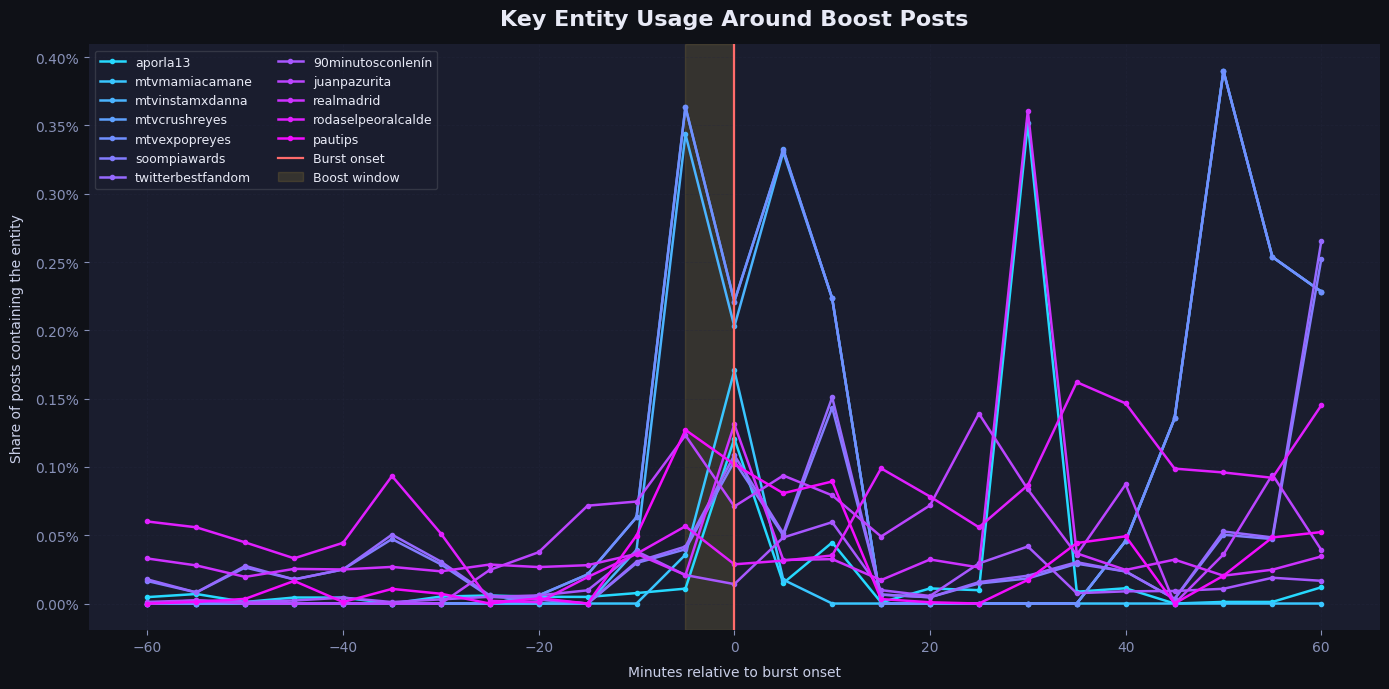

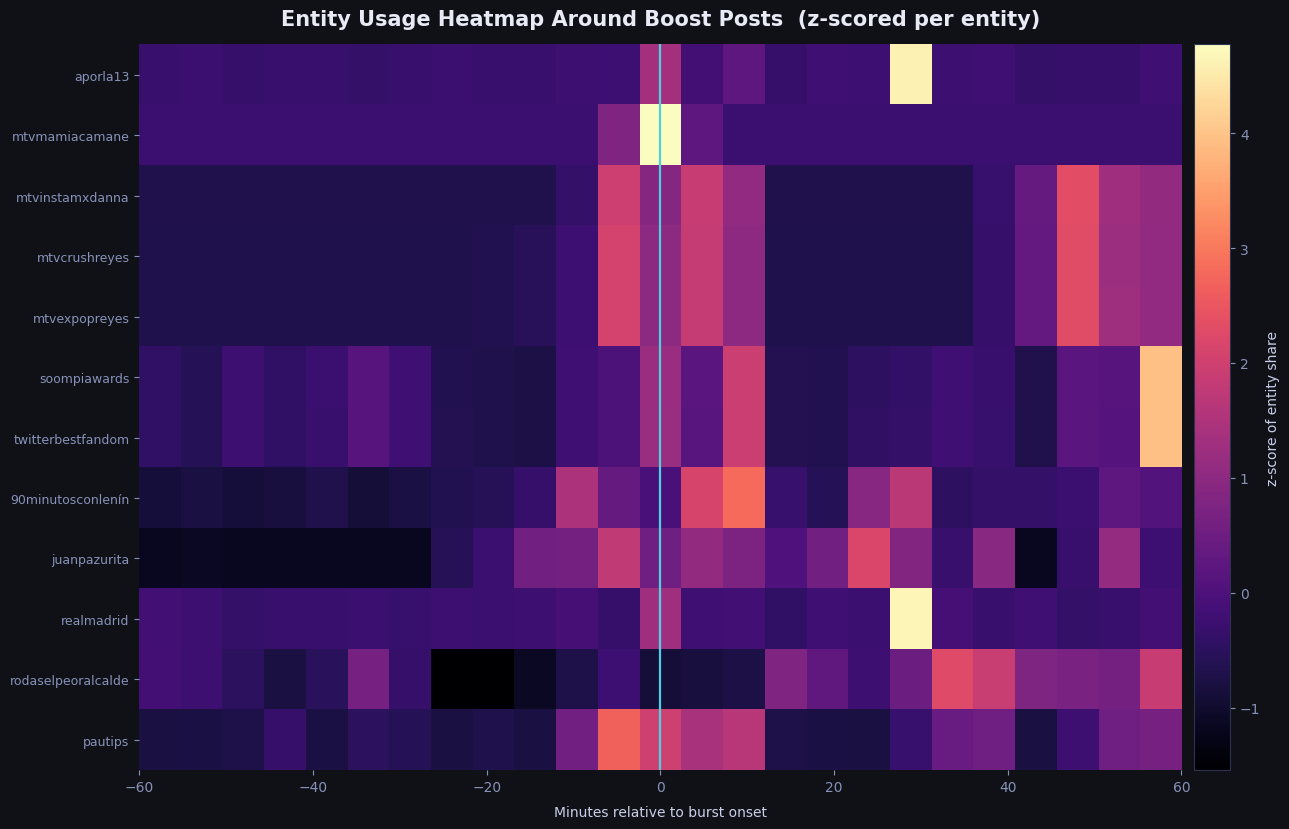

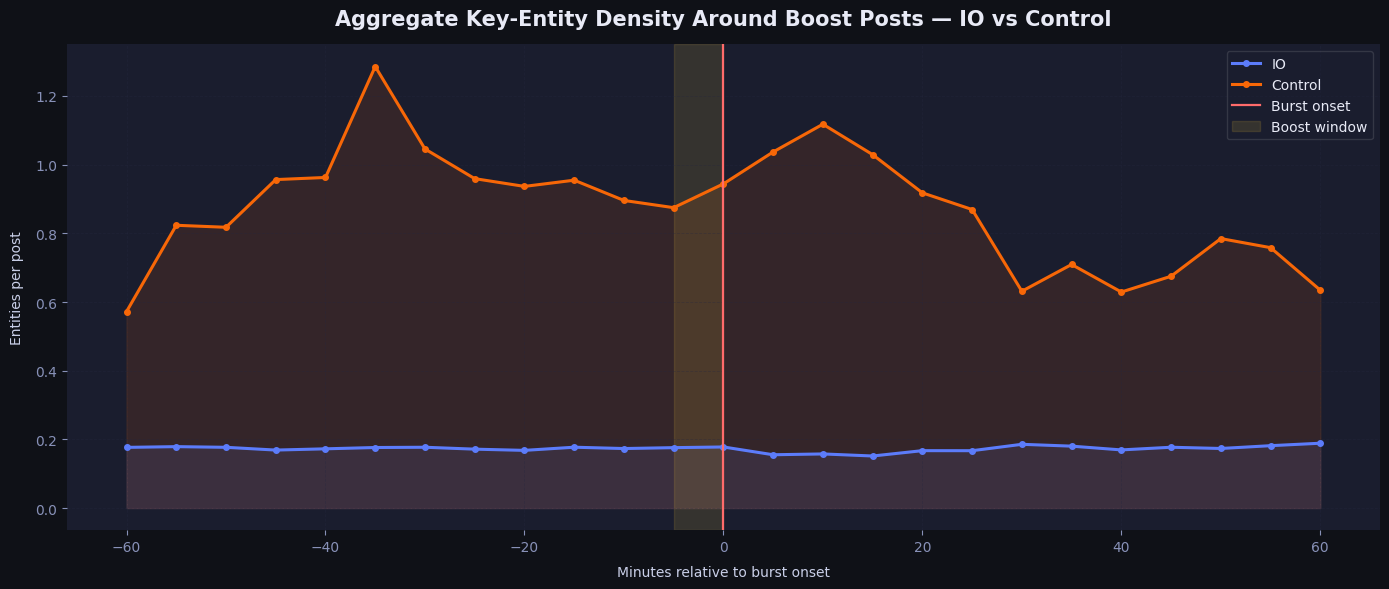

In [39]:
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor": "#1a1d2e",
    "axes.edgecolor": "#2e3250",
    "axes.labelcolor": "#c9cfe8",
    "xtick.color": "#8891b8",
    "ytick.color": "#8891b8",
    "text.color": "#e8eaf6",
    "grid.color": "#252840",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "font.family": "DejaVu Sans",
})


def mark_burst_axes(ax) -> None:
    """Draw the boost window and burst onset markers on a peri-burst axis.

    Args:
        ax: Matplotlib axis to annotate.
    """
    ax.axvline(0, color="#ff6b6b", linewidth=1.6, linestyle="-", label="Burst onset")
    ax.axvspan(-BIN_MINUTES, 0, color="#ffd43b", alpha=0.12, label="Boost window")


# -- 1. Line plot: share of volume per entity around the burst -----------------
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.cool(np.linspace(0.15, 0.95, len(top_entities)))
for entity, color in zip(top_entities, colors):
    ax.plot(rel_minutes, share_all[entity].to_numpy(), color=color,
            linewidth=1.8, marker="o", markersize=3, label=entity)

mark_burst_axes(ax)
ax.set_title("Key Entity Usage Around Boost Posts", fontsize=16, fontweight="bold",
             color="#e8eaf6", pad=14)
ax.set_xlabel("Minutes relative to burst onset", labelpad=8)
ax.set_ylabel("Share of posts containing the entity", labelpad=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))
ax.grid(alpha=0.35)
ax.spines[:].set_visible(False)
ax.legend(framealpha=0.15, fontsize=9, ncol=2, loc="upper left")
plt.tight_layout()
plt.savefig(output_path / "entity_peri_burst_lines.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# -- 2. Heatmap: entity x relative time, z-scored per entity -------------------
heat = share_all[top_entities].to_numpy().T
heat = (heat - heat.mean(axis=1, keepdims=True)) / np.where(
    heat.std(axis=1, keepdims=True) == 0, np.nan, heat.std(axis=1, keepdims=True)
)

fig, ax = plt.subplots(figsize=(14, 0.45 * len(top_entities) + 3))
mesh = ax.imshow(heat, aspect="auto", cmap="magma", origin="upper",
                 extent=[rel_minutes[0], rel_minutes[-1], len(top_entities) - 0.5, -0.5])
ax.axvline(0, color="#4dd0e1", linewidth=1.6)
ax.set_yticks(range(len(top_entities)))
ax.set_yticklabels(top_entities, fontsize=9)
ax.set_xlabel("Minutes relative to burst onset", labelpad=8)
ax.set_title("Entity Usage Heatmap Around Boost Posts  (z-scored per entity)",
             fontsize=15, fontweight="bold", color="#e8eaf6", pad=14)
cbar = fig.colorbar(mesh, ax=ax, pad=0.01)
cbar.set_label("z-score of entity share", color="#c9cfe8")
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig(output_path / "entity_peri_burst_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# -- 3. IO vs Control: aggregate entity share around the burst -----------------
fig, ax = plt.subplots(figsize=(14, 6))
for flag, color, label in [(False, COLOR_IO, "IO"), (True, COLOR_CONTROL, "Control")]:
    subset = ent[ent["is_control"] == flag]
    if subset.empty:
        continue
    counts_g, volume_g_grp = peri_burst_profile(
        subset, group_mask=(df["is_control"] == flag).to_numpy()
    )
    agg = counts_g.sum(axis=1) / np.where(volume_g_grp == 0, np.nan, volume_g_grp)
    ax.plot(rel_minutes, agg.to_numpy(), color=color, linewidth=2.2,
            marker="o", markersize=4, label=label)
    ax.fill_between(rel_minutes, agg.to_numpy(), alpha=0.12, color=color)

mark_burst_axes(ax)
ax.set_title("Aggregate Key-Entity Density Around Boost Posts — IO vs Control",
             fontsize=15, fontweight="bold", color="#e8eaf6", pad=14)
ax.set_xlabel("Minutes relative to burst onset", labelpad=8)
ax.set_ylabel("Entities per post", labelpad=8)
ax.grid(alpha=0.35)
ax.spines[:].set_visible(False)
ax.legend(framealpha=0.15, fontsize=10)
plt.tight_layout()
plt.savefig(output_path / "entity_peri_burst_io_vs_control.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## Deliverable 3 — Validation report on the boost scoring approach

Everything above is descriptive. This section asks whether the score actually
works, and writes the answer to `boost_validation_report.txt`.

The central check is the **activity confound**. `boost_score` sums credit over
every burst an account preceded, so an account that posts more often falls inside
more pre-burst windows and accumulates more score by construction. The report
therefore reports two baselines next to the score itself:

- `n_posts` alone — if this reaches a similar AUC, the boost score adds nothing
- `boost_score / n_posts` — if this collapses to chance, the signal was volume

The `verdict` at the end of the report is derived from those two numbers rather
than written in advance.

Also included: AUC over all accounts (unscored accounts enter as 0, otherwise the
AUC is inflated), Cliff's delta, Mann-Whitney, precision@k and lift against the
base rate, per-group coverage, a permutation null that shuffles `accountid` while
holding `post_time` fixed (same volume series, same bursts, only the identity of
the pre-burst posters changes), and a sensitivity sweep over `FREQ` and
`Z_THRESHOLD`.

Set `RUN_SWEEP = False` to skip the sweep, which is the expensive part.

In [40]:
import math

import numpy as np
import pandas as pd

try:
    from scipy.stats import mannwhitneyu, spearmanr
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False

# ---------------------------------------------------------------- parameters
N_PERMUTATIONS = 20
PRECISION_KS = (10, 50, 100, 500, 1000)
SWEEP_FREQS = ("1min", "5min", "15min")
SWEEP_Z = (2.0, 3.0, 4.0)
RUN_SWEEP = True            # the sweep re-runs the pipeline once per grid cell
RANDOM_SEED = 0

rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------- sorted views for fast lookup
order = np.argsort(df["post_time"].to_numpy(), kind="mergesort")
times_sorted = pd.DatetimeIndex(df["post_time"].to_numpy()[order])
accounts_sorted = df["accountid"].to_numpy()[order]

account_labels = df.groupby("accountid")["is_control"].first()
posts_per_account = df["accountid"].value_counts().reindex(account_labels.index, fill_value=0)
all_accounts = account_labels.index
is_io = ~account_labels.astype(bool)
base_rate = float(is_io.mean())

write_report(
    f"Validation universe: {len(all_accounts):,} accounts, "
    f"IO base rate {base_rate:.3f}"
)


def burst_table(freq: str, z_threshold: float):
    """Detect burst windows on the global volume series.

    Args:
        freq: Resampling frequency for the volume series.
        z_threshold: Minimum z-score of the volume delta.

    Returns:
        Tuple of (burst timestamps, volume deltas at those timestamps).
    """
    volume = pd.Series(1.0, index=times_sorted).resample(freq).sum()
    delta = volume.diff().dropna()
    z = (delta - delta.mean()) / delta.std()
    hit = z > z_threshold
    return delta.index[hit], delta[hit].to_numpy()


def boost_scores(burst_times, deltas, accounts, freq: str) -> pd.Series:
    """Reproduce the notebook's boost attribution for a given account vector.

    Credit for each burst is split evenly across the accounts that posted in
    the preceding window, matching the logic of the pipeline cell above.

    Args:
        burst_times: Timestamps of detected bursts.
        deltas: Volume delta at each burst.
        accounts: Account id per post, aligned to times_sorted.
        freq: Window length, equal to the binning frequency.

    Returns:
        Boost score per account id.
    """
    window = pd.Timedelta(freq)
    lo = np.searchsorted(times_sorted.to_numpy(), (burst_times - window).to_numpy(), "left")
    hi = np.searchsorted(times_sorted.to_numpy(), burst_times.to_numpy(), "left")

    totals: dict = {}
    for start, end, delta in zip(lo, hi, deltas):
        if end <= start:
            continue
        users = pd.unique(accounts[start:end])
        weight = delta / len(users)
        for user in users:
            totals[user] = totals.get(user, 0.0) + weight
    return pd.Series(totals, dtype=float)


def as_full_vector(scores: pd.Series) -> pd.Series:
    """Expand a score series over every account, filling unscored ones with zero.

    Args:
        scores: Boost score per scored account.

    Returns:
        Score per account over the full account universe.
    """
    return scores.reindex(all_accounts).fillna(0.0)


def auc_io(scores: pd.Series) -> float:
    """Rank-based AUC for separating IO accounts from control accounts.

    Args:
        scores: Score per account, indexed like the label series.

    Returns:
        AUC with IO as the positive class, or NaN if a class is absent.
    """
    labels = is_io.reindex(scores.index).to_numpy()
    n_pos, n_neg = labels.sum(), (~labels).sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    ranks = scores.rank(method="average").to_numpy()
    return float((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def roc_curve(scores: pd.Series):
    """Compute an ROC curve without external dependencies.

    Args:
        scores: Score per account.

    Returns:
        Tuple of (false positive rate, true positive rate) arrays.
    """
    labels = is_io.reindex(scores.index).to_numpy()
    ordering = np.argsort(-scores.to_numpy(), kind="mergesort")
    labels = labels[ordering]
    tpr = np.concatenate([[0.0], np.cumsum(labels) / labels.sum()])
    fpr = np.concatenate([[0.0], np.cumsum(~labels) / (~labels).sum()])
    return fpr, tpr


def precision_at_k(scores: pd.Series, k: int) -> float:
    """Share of IO accounts among the k highest-scoring accounts.

    Args:
        scores: Score per account.
        k: Number of top accounts to inspect.

    Returns:
        Precision at k, or NaN if fewer than k accounts are available.
    """
    if k > len(scores):
        return float("nan")
    top = scores.sort_values(ascending=False).head(k).index
    return float(is_io.reindex(top).mean())


# ----------------------------------------------------- observed score vectors
observed = as_full_vector(boost_scores_g)
volume_baseline = posts_per_account.astype(float)
per_post = observed / volume_baseline.replace(0, np.nan)
per_post = per_post.fillna(0.0)

auc_observed = auc_io(observed)
auc_volume = auc_io(volume_baseline)
auc_per_post = auc_io(per_post)
auc_scored_only = auc_io(boost_scores_g[boost_scores_g.index.isin(all_accounts)])

# --------------------------------------------------------------- effect sizes
io_scores = observed[is_io.to_numpy()]
control_scores = observed[~is_io.to_numpy()]
cliffs_delta = 2 * auc_observed - 1

if HAVE_SCIPY:
    mw_stat, mw_p = mannwhitneyu(io_scores, control_scores, alternative="two-sided")
    rho, rho_p = spearmanr(observed, volume_baseline)
else:
    n_pos, n_neg = len(io_scores), len(control_scores)
    mean_u = n_pos * n_neg / 2
    sd_u = np.sqrt(n_pos * n_neg * (n_pos + n_neg + 1) / 12)
    mw_stat = auc_observed * n_pos * n_neg
    z_stat = (mw_stat - mean_u) / sd_u
    mw_p = 2 * (1 - 0.5 * (1 + math.erf(abs(z_stat) / np.sqrt(2))))
    rho = float(np.corrcoef(observed.rank(), volume_baseline.rank())[0, 1])
    rho_p = float("nan")

# ------------------------------------------------------------------- coverage
coverage = pd.DataFrame({
    "n_accounts": [int(is_io.sum()), int((~is_io).sum())],
    "n_scored": [int((observed[is_io.to_numpy()] > 0).sum()),
                 int((observed[~is_io.to_numpy()] > 0).sum())],
}, index=["IO", "Control"])
coverage["share_scored"] = coverage["n_scored"] / coverage["n_accounts"]

# ------------------------------------------------------------- precision at k
precision_table = pd.DataFrame({
    "k": PRECISION_KS,
    "precision_boost": [precision_at_k(observed, k) for k in PRECISION_KS],
    "precision_volume": [precision_at_k(volume_baseline, k) for k in PRECISION_KS],
})
precision_table["base_rate"] = base_rate
precision_table["lift_boost"] = precision_table["precision_boost"] / base_rate
precision_table["lift_volume"] = precision_table["precision_volume"] / base_rate

# --------------------------------- permutation null: shuffle account ownership
burst_times_obs, deltas_obs = burst_table(FREQ, Z_THRESHOLD)
null_aucs = []
for _ in range(N_PERMUTATIONS):
    shuffled = rng.permutation(accounts_sorted)
    null_scores = as_full_vector(boost_scores(burst_times_obs, deltas_obs, shuffled, FREQ))
    null_aucs.append(auc_io(null_scores))
null_aucs = np.array(null_aucs, dtype=float)
null_p = (1 + int((np.abs(null_aucs - 0.5) >= abs(auc_observed - 0.5)).sum())) / (N_PERMUTATIONS + 1)

write_report(
    f"AUC observed {auc_observed:.4f} | volume baseline {auc_volume:.4f} | "
    f"per-post {auc_per_post:.4f} | permutation p {null_p:.4f}"
)

# ----------------------------------------------------------- parameter sweep
sweep_rows = []
if RUN_SWEEP:
    for freq in SWEEP_FREQS:
        for z_threshold in SWEEP_Z:
            times_b, deltas_b = burst_table(freq, z_threshold)
            if len(times_b) == 0:
                sweep_rows.append((freq, z_threshold, 0, 0, float("nan")))
                continue
            scores_b = boost_scores(times_b, deltas_b, accounts_sorted, freq)
            sweep_rows.append((freq, z_threshold, len(times_b), len(scores_b),
                               auc_io(as_full_vector(scores_b))))
            write_report(f"sweep {freq} z>{z_threshold}: {len(times_b)} bursts, "
                         f"AUC {sweep_rows[-1][4]:.4f}")

sweep_table = pd.DataFrame(
    sweep_rows, columns=["freq", "z_threshold", "n_bursts", "n_scored_accounts", "auc"]
)

precision_table.to_csv(output_path / "validation_precision_at_k.csv", index=False)
coverage.to_csv(output_path / "validation_coverage.csv")
sweep_table.to_csv(output_path / "validation_parameter_sweep.csv", index=False)
print(precision_table.to_string(index=False))
print(sweep_table.to_string(index=False))

2026-07-27 06:36:31 | Validation universe: 21,924 accounts, IO base rate 0.036
2026-07-27 06:36:38 | AUC observed 0.6483 | volume baseline 0.6493 | per-post 0.6094 | permutation p 0.0476
2026-07-27 06:36:39 | sweep 1min z>2.0: 60696 bursts, AUC 0.6804
2026-07-27 06:36:40 | sweep 1min z>3.0: 28466 bursts, AUC 0.6853
2026-07-27 06:36:41 | sweep 1min z>4.0: 21503 bursts, AUC 0.6742
2026-07-27 06:36:41 | sweep 5min z>2.0: 9854 bursts, AUC 0.6827
2026-07-27 06:36:41 | sweep 5min z>3.0: 5940 bursts, AUC 0.6483
2026-07-27 06:36:41 | sweep 5min z>4.0: 3909 bursts, AUC 0.6312
2026-07-27 06:36:42 | sweep 15min z>2.0: 3536 bursts, AUC 0.7069
2026-07-27 06:36:42 | sweep 15min z>3.0: 2120 bursts, AUC 0.6987
2026-07-27 06:36:42 | sweep 15min z>4.0: 1378 bursts, AUC 0.6739
   k  precision_boost  precision_volume  base_rate  lift_boost  lift_volume
  10            1.000             1.000   0.035897   27.857687    27.857687
  50            1.000             1.000   0.035897   27.857687    27.857687
 10

### Plots for deliverable 3

`validation_overview.png` — four panels: ROC for the boost score against both
baselines, precision@k against the base rate, the boost-versus-activity scatter
with its Spearman rho, and the permutation null distribution with the observed
AUC marked.

`validation_parameter_sweep.png` — AUC across the `FREQ` x `Z_THRESHOLD` grid.
If the AUC flips sign across this grid, the choice of 5min and z>3 needs a
justification in the paper.

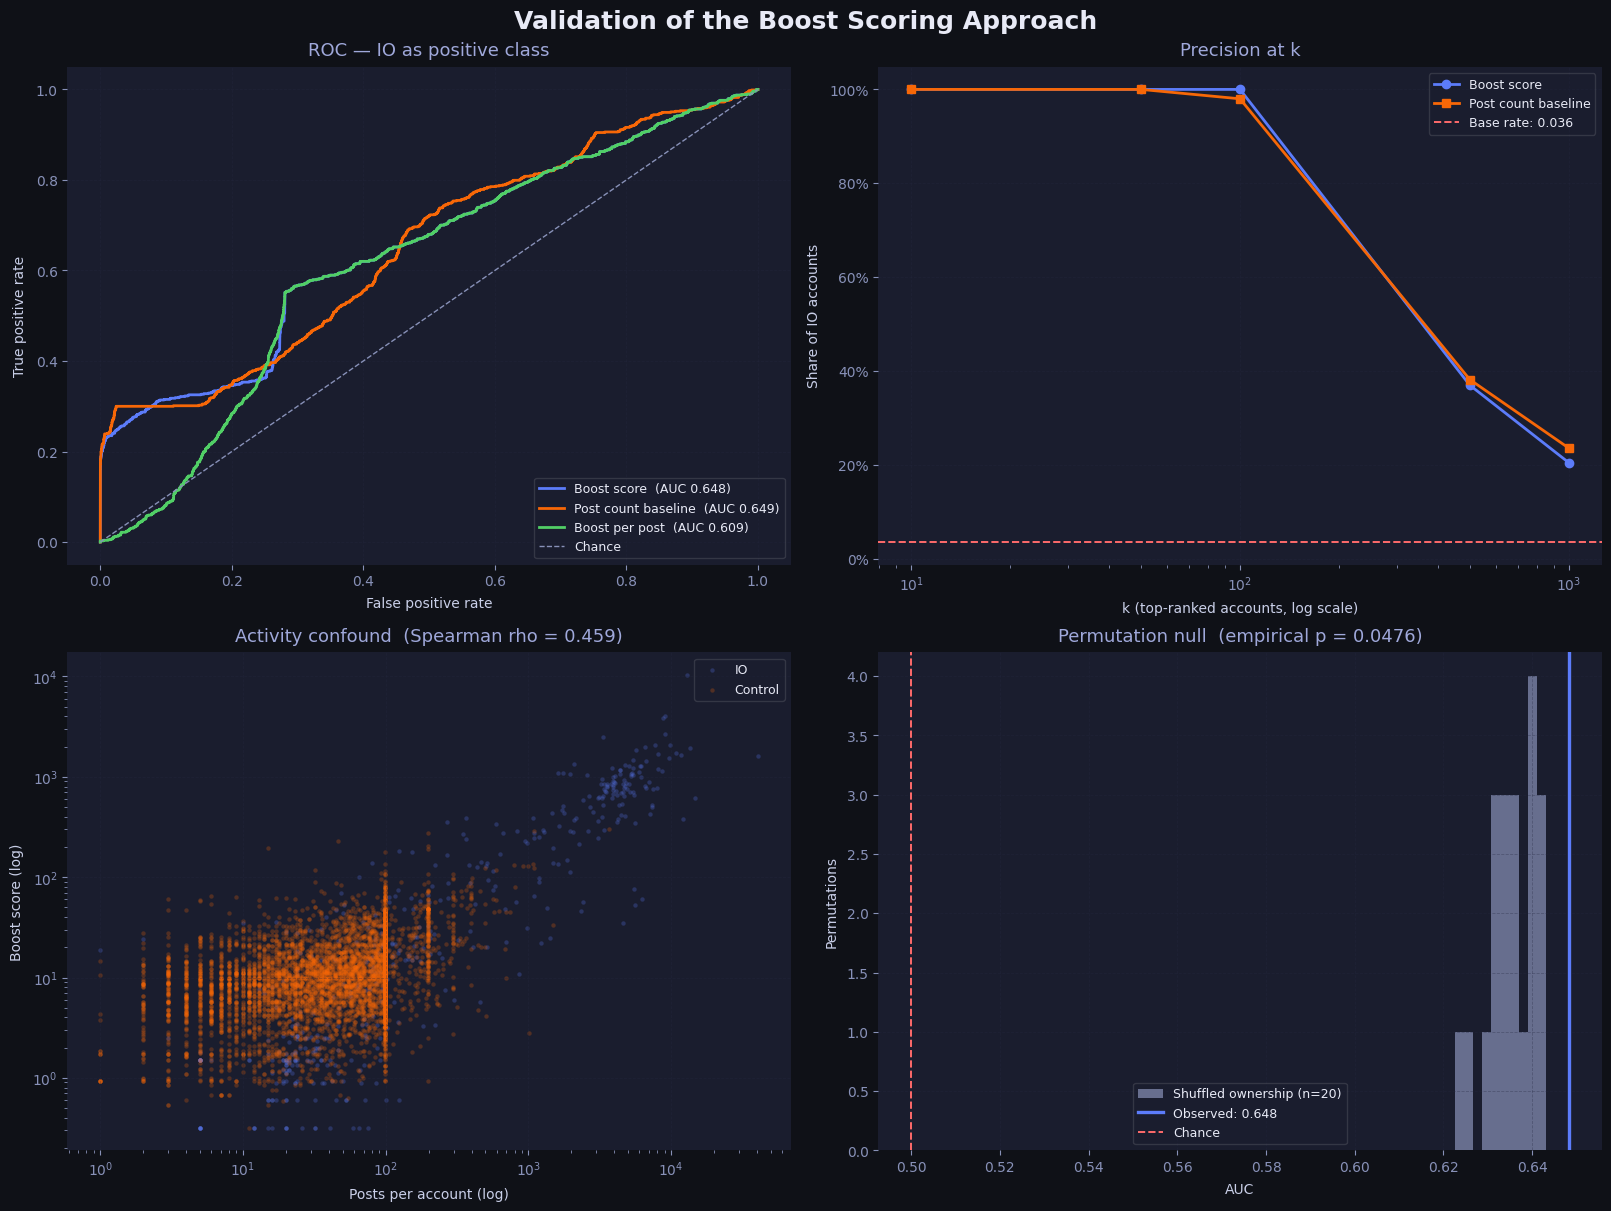

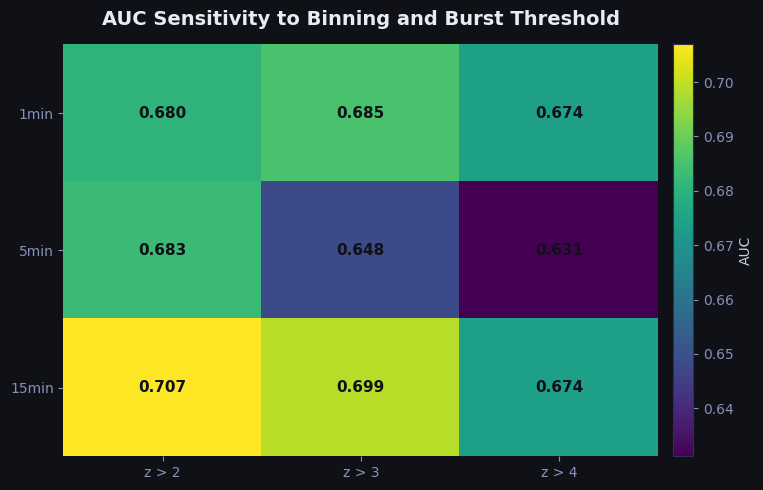

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor": "#1a1d2e",
    "axes.edgecolor": "#2e3250",
    "axes.labelcolor": "#c9cfe8",
    "xtick.color": "#8891b8",
    "ytick.color": "#8891b8",
    "text.color": "#e8eaf6",
    "grid.color": "#252840",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "font.family": "DejaVu Sans",
})

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Validation of the Boost Scoring Approach", fontsize=18,
             fontweight="bold", color="#e8eaf6")

# -- ROC: boost vs volume baseline vs activity-normalized ----------------------
ax = axes[0, 0]
for vector, color, label, value in [
    (observed, "#5c7cfa", "Boost score", auc_observed),
    (volume_baseline, "#f76707", "Post count baseline", auc_volume),
    (per_post, "#51cf66", "Boost per post", auc_per_post),
]:
    fpr, tpr = roc_curve(vector)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{label}  (AUC {value:.3f})")
ax.plot([0, 1], [0, 1], color="#8891b8", linewidth=1, linestyle="--", label="Chance")
ax.set_title("ROC — IO as positive class", fontsize=13, color="#9fa8da", pad=8)
ax.set_xlabel("False positive rate", labelpad=6)
ax.set_ylabel("True positive rate", labelpad=6)
ax.legend(framealpha=0.15, fontsize=9, loc="lower right")
ax.grid(alpha=0.35)
ax.spines[:].set_visible(False)

# -- Precision at k -----------------------------------------------------------
ax = axes[0, 1]
ax.plot(precision_table["k"], precision_table["precision_boost"], color="#5c7cfa",
        marker="o", linewidth=2, label="Boost score")
ax.plot(precision_table["k"], precision_table["precision_volume"], color="#f76707",
        marker="s", linewidth=2, label="Post count baseline")
ax.axhline(base_rate, color="#ff6b6b", linestyle="--", linewidth=1.4,
           label=f"Base rate: {base_rate:.3f}")
ax.set_xscale("log")
ax.set_title("Precision at k", fontsize=13, color="#9fa8da", pad=8)
ax.set_xlabel("k (top-ranked accounts, log scale)", labelpad=6)
ax.set_ylabel("Share of IO accounts", labelpad=6)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(framealpha=0.15, fontsize=9)
ax.grid(alpha=0.35)
ax.spines[:].set_visible(False)

# -- Confound: boost score vs raw activity ------------------------------------
ax = axes[1, 0]
for flag, color, label in [(True, "#5c7cfa", "IO"), (False, "#f76707", "Control")]:
    mask = is_io.to_numpy() == flag
    ax.scatter(volume_baseline[mask], observed[mask], s=10, alpha=0.25,
               color=color, linewidths=0, label=label)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Activity confound  (Spearman rho = {rho:.3f})", fontsize=13,
             color="#9fa8da", pad=8)
ax.set_xlabel("Posts per account (log)", labelpad=6)
ax.set_ylabel("Boost score (log)", labelpad=6)
ax.legend(framealpha=0.15, fontsize=9)
ax.grid(alpha=0.35)
ax.spines[:].set_visible(False)

# -- Permutation null ---------------------------------------------------------
ax = axes[1, 1]
ax.hist(null_aucs, bins=max(8, N_PERMUTATIONS // 2), color="#8891b8", alpha=0.7,
        edgecolor="none", label=f"Shuffled ownership (n={N_PERMUTATIONS})")
ax.axvline(auc_observed, color="#5c7cfa", linewidth=2.4,
           label=f"Observed: {auc_observed:.3f}")
ax.axvline(0.5, color="#ff6b6b", linewidth=1.4, linestyle="--", label="Chance")
ax.set_title(f"Permutation null  (empirical p = {null_p:.4f})", fontsize=13,
             color="#9fa8da", pad=8)
ax.set_xlabel("AUC", labelpad=6)
ax.set_ylabel("Permutations", labelpad=6)
ax.legend(framealpha=0.15, fontsize=9)
ax.grid(alpha=0.35)
ax.spines[:].set_visible(False)

plt.savefig(output_path / "validation_overview.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# -- Parameter sweep heatmap --------------------------------------------------
if RUN_SWEEP and not sweep_table["auc"].isna().all():
    grid = sweep_table.pivot(index="freq", columns="z_threshold", values="auc")
    grid = grid.reindex(index=list(SWEEP_FREQS))

    fig, ax = plt.subplots(figsize=(8, 5))
    mesh = ax.imshow(grid.to_numpy(), cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(grid.columns)), [f"z > {c:g}" for c in grid.columns])
    ax.set_yticks(range(len(grid.index)), grid.index)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            value = grid.to_numpy()[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.3f}", ha="center", va="center",
                        color="#0f1117", fontsize=11, fontweight="bold")
    ax.set_title("AUC Sensitivity to Binning and Burst Threshold", fontsize=14,
                 fontweight="bold", color="#e8eaf6", pad=14)
    fig.colorbar(mesh, ax=ax, pad=0.02).set_label("AUC", color="#c9cfe8")
    ax.spines[:].set_visible(False)
    plt.tight_layout()
    plt.savefig(output_path / "validation_parameter_sweep.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

### Writing the report

Assembles the numbers above into `boost_validation_report.txt` under
`output_path`, in seven sections plus a limitations block covering the global
z-score baseline, the even credit split across pre-burst posters, and the fact
that the control group is gathered rather than sampled.

In [42]:
def verdict(observed_auc: float, baseline_auc: float, normalized_auc: float) -> str:
    """Summarize whether the boost score adds signal over raw activity.

    Args:
        observed_auc: AUC of the boost score.
        baseline_auc: AUC of the post-count baseline.
        normalized_auc: AUC of the activity-normalized boost score.

    Returns:
        A short verdict line for the report.
    """
    margin = observed_auc - baseline_auc
    if margin <= 0.01:
        return ("The boost score does not separate IO from control accounts better than "
                "raw post count. On this dataset it behaves as an activity proxy.")
    if normalized_auc <= 0.55:
        return ("The boost score beats the post-count baseline, but the advantage "
                "disappears once scores are divided by posting volume, so part of the "
                "signal is carried by activity rather than timing.")
    return ("The boost score separates IO from control accounts beyond the post-count "
            "baseline, and the advantage survives normalization by posting volume.")


report_lines = [
    "VALIDATION REPORT — BOOST SCORING",
    "=" * 72,
    "",
    f"Dataset          : {input_data_path}",
    f"Posts            : {len(df):,}",
    f"Accounts         : {len(all_accounts):,}",
    f"IO base rate     : {base_rate:.4f}",
    f"Binning          : {FREQ}, burst threshold z > {Z_THRESHOLD}",
    f"Bursts detected  : {len(burst_times_obs):,}",
    f"Accounts scored  : {int((observed > 0).sum()):,} "
    f"({(observed > 0).mean():.1%} of the universe)",
    "",
    "1. DISCRIMINATIVE POWER (IO as positive class)",
    "-" * 72,
    f"AUC, boost score, all accounts        : {auc_observed:.4f}",
    f"AUC, boost score, scored accounts only: {auc_scored_only:.4f}",
    f"AUC, post-count baseline              : {auc_volume:.4f}",
    f"AUC, boost score per post             : {auc_per_post:.4f}",
    f"Margin over baseline                  : {auc_observed - auc_volume:+.4f}",
    f"Cliff's delta                         : {cliffs_delta:+.4f}",
    f"Mann-Whitney p                        : {mw_p:.3e}"
    + ("" if HAVE_SCIPY else "   (normal approximation, scipy unavailable)"),
    "",
    "2. ACTIVITY CONFOUND",
    "-" * 72,
    f"Spearman rho, boost score vs post count: {rho:.4f}"
    + (f"  (p = {rho_p:.3e})" if HAVE_SCIPY else ""),
    "A high correlation is expected by construction: accounts that post more often",
    "fall inside more pre-burst windows and therefore accumulate more credit.",
    "",
    "3. RANKING QUALITY",
    "-" * 72,
    precision_table.to_string(index=False),
    "",
    "4. COVERAGE",
    "-" * 72,
    coverage.to_string(),
    "",
    "5. PERMUTATION NULL (account ownership shuffled, burst times fixed)",
    "-" * 72,
    f"Permutations   : {N_PERMUTATIONS}",
    f"Null AUC mean  : {null_aucs.mean():.4f}  (sd {null_aucs.std():.4f})",
    f"Observed AUC   : {auc_observed:.4f}",
    f"Empirical p    : {null_p:.4f}",
    "This null preserves the volume series and the burst times, so it isolates",
    "whether the identity of the pre-burst posters carries information.",
    "",
    "6. PARAMETER SENSITIVITY",
    "-" * 72,
    sweep_table.to_string(index=False) if RUN_SWEEP else "Sweep disabled (RUN_SWEEP=False).",
    "",
    "7. VERDICT",
    "-" * 72,
    verdict(auc_observed, auc_volume, auc_per_post),
    "",
    "LIMITATIONS",
    "-" * 72,
    "The z-score uses the mean and standard deviation of the whole delta series,",
    "so burst detection is sensitive to trend and to diurnal seasonality. A rolling",
    "baseline would make the burst set more stable.",
    "Credit is split evenly across every account posting in the pre-burst window,",
    "so the score does not distinguish an account that triggered a cascade from one",
    "that happened to post nearby.",
    "The control group is gathered rather than sampled, so the AUC above measures",
    "separation on this dataset and is not an estimate of deployment performance.",
]

report_text = "\n".join(report_lines)
report_file = output_path / "boost_validation_report.txt"
report_file.write_text(report_text, encoding="utf-8")
write_report(f"Wrote {report_file}")
print(report_text)

2026-07-27 06:36:46 | Wrote ../results/Ecuador/step_Boost/boost_validation_report.txt
VALIDATION REPORT — BOOST SCORING

Dataset          : /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador
Posts            : 1,470,529
Accounts         : 21,924
IO base rate     : 0.0359
Binning          : 5min, burst threshold z > 3
Bursts detected  : 5,940
Accounts scored  : 6,368 (29.0% of the universe)

1. DISCRIMINATIVE POWER (IO as positive class)
------------------------------------------------------------------------
AUC, boost score, all accounts        : 0.6483
AUC, boost score, scored accounts only: 0.5834
AUC, post-count baseline              : 0.6493
AUC, boost score per post             : 0.6094
Margin over baseline                  : -0.0011
Cliff's delta                         : +0.2965
Mann-Whitney p                        : 1.099e-69

2. ACTIVITY CONFOUND
------------------------------------------------------------------------
Spearman rho, boost score vs post count: